# Experiment: ARX Greenhouse Identification Study

Objective:
- Evaluate the ARX greenhouse baseline with the structure and evidence density expected in a research-style report.
- Emphasize full-year data coverage, parameter recovery, long-horizon prediction, residual diagnostics, and model-structure tradeoffs.


## Study Questions

- Does the baseline ARX(2,2,1) recover the true physical direction of each actuator and disturbance term?
- How far does free-run performance fall relative to one-step prediction, and is that gap explained by process noise?
- Which diagnostic plots are needed to argue that the model is statistically defensible rather than merely visually plausible?


## Workflow

1. Configure the experiment and plotting style.
2. Run the full pipeline and cache all derived tables.
3. Characterize the dataset and operating regime.
4. Analyze parameter recovery, prediction quality, residual behavior, and model selection.
5. Conclude with strengths, limits, and what the baseline can and cannot support.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

from arx_pipeline import DataConfig, ModelConfig, SplitConfig, run_pipeline, save_artifact
from arx_reporting import (
    behavior_frame,
    combined_prediction_frame,
    contribution_frame,
    grouped_metrics,
    impulse_response_frame,
    model_comparison_frame,
    monthly_actuator_summary,
    monthly_setpoint_summary,
    monthly_signal_summary,
    parameter_frame,
    rolling_rmse,
    selection_metric_grid,
    standardized_parameter_frame,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

DATA_CONFIG = DataConfig(
    csv_path=Path('greenhouse_data.csv'),
    generator_script_path=Path('data_generator.py'),
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
    generated_days=365,
    generated_sampling_seconds=300,
    generated_seed=42,
    generated_start_date='2025-01-01',
)
SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)
MODEL_CONFIG = ModelConfig(na=2, nb=2, nk=1, include_intercept=False)

def plot_heatmap(ax, grid_df, title, cmap='viridis', fmt='{:.3f}'):
    if grid_df.empty:
        ax.set_visible(False)
        return
    data = grid_df.to_numpy(dtype=float)
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(grid_df.columns)))
    ax.set_xticklabels(grid_df.columns.tolist())
    ax.set_yticks(range(len(grid_df.index)))
    ax.set_yticklabels(grid_df.index.tolist())
    ax.set_xlabel('nb')
    ax.set_ylabel('na')
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, fmt.format(data[i, j]), ha='center', va='center', color='white', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def display_research_note(title, lines):
    payload = [f'### {title}', ''] + [f'- {line}' for line in lines]
    display(Markdown('\n'.join(payload)))


In [2]:
results = run_pipeline(DATA_CONFIG, SPLIT_CONFIG, MODEL_CONFIG)
save_artifact(results)

df_full = results['df_full']
df_train = results['df_train']
df_val = results['df_val']
df_test = results['df_test']

behavior_df = behavior_frame(results)
params_df = parameter_frame(results)
std_param_df = standardized_parameter_frame(results, split_key='train')
contrib_df = contribution_frame(results, split_key='train')
impulse_df = impulse_response_frame(results, split_key='train', horizon=48, pulse_mode='std')
prediction_df = combined_prediction_frame(results)
monthly_signal_df = monthly_signal_summary(df_full)
monthly_actuator_df = monthly_actuator_summary(df_full)
monthly_setpoint_df = monthly_setpoint_summary(df_full)
monthly_metrics_df = grouped_metrics(prediction_df[prediction_df['split'].isin(['Validation', 'Test'])], ['split', 'Month'])
model_cmp_df = model_comparison_frame(results)
selection_df = results['model_selection'].copy()
selection_grid_nk1 = selection_metric_grid(selection_df, 'RMSE_sim', nk=1)
selection_grid_nk2 = selection_metric_grid(selection_df, 'RMSE_sim', nk=2)

overview = results['dataset_overview']
summary_series = pd.Series({
    'data_source': results['data_source'],
    'rows': overview['rows'],
    'timestamp_start': overview['timestamp_start'],
    'timestamp_end': overview['timestamp_end'],
    'months_present': overview['months_present'],
    'seasons_present': overview['seasons_present'],
    'rank_x_train': overview['rank_x_train'],
    'n_params': overview['n_params'],
    'condition_number_xtx': round(overview['condition_number_xtx'], 2),
    'sign_ok_count': int(params_df['sign_ok'].sum()),
    'sign_total_count': int(len(params_df)),
    'val_fit_1step': round(results['val']['metrics_1step']['FIT'], 3),
    'val_fit_12step': round(results['val']['metrics_n_step']['FIT'], 3),
    'val_fit_sim': round(results['val']['metrics_sim']['FIT'], 3),
    'test_fit_sim': round(results['test']['metrics_sim']['FIT'], 3),
    'val_theoretical_fit_sim': round(results['val'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 3),
    'test_theoretical_fit_sim': round(results['test'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 3),
})


## Executive Evaluation

The notebook should not stop at a pretty one-step score. A defensible identification result must combine:
- representative data coverage,
- parameter signs consistent with the generating physics,
- residuals that behave like unexplained noise,
- and long-horizon performance interpreted relative to the deterministic ceiling.


In [3]:
key_findings = pd.DataFrame(
    [
        {'Finding': 'Full-year coverage', 'Evidence': f"{summary_series['months_present']}"},
        {'Finding': 'Parameter sign recovery', 'Evidence': f"{summary_series['sign_ok_count']} / {summary_series['sign_total_count']} correct"},
        {'Finding': 'Validation one-step FIT', 'Evidence': f"{summary_series['val_fit_1step']:.3f}%"},
        {'Finding': 'Validation free-run FIT', 'Evidence': f"{summary_series['val_fit_sim']:.3f}%"},
        {'Finding': 'Validation deterministic ceiling', 'Evidence': f"{summary_series['val_theoretical_fit_sim']:.3f}%"},
        {'Finding': 'Residual whiteness on validation', 'Evidence': str(results['val']['residual_diagnostics']['ljung_box']['passes_all_lags'])},
    ]
)
summary_series, key_findings


(data_source                                 CSV:greenhouse_data.csv
 rows                                                         105120
 timestamp_start                                 2025-01-01 00:00:00
 timestamp_end                                   2025-12-31 23:55:00
 months_present              [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
 seasons_present                    [autumn, spring, summer, winter]
 rank_x_train                                                     14
 n_params                                                         14
 condition_number_xtx                                    56303331.05
 sign_ok_count                                                    14
 sign_total_count                                                 14
 val_fit_1step                                                91.641
 val_fit_12step                                               73.109
 val_fit_sim                                                  42.959
 test_fit_sim                     

## Experimental Setup

This section documents the baseline configuration and the operating statistics of each split. In a paper, this is the minimum needed to interpret the downstream metrics.


In [4]:
config_df = pd.DataFrame(
    [
        {'Block': 'Data', 'Setting': 'Source', 'Value': results['data_source']},
        {'Block': 'Data', 'Setting': 'Days', 'Value': DATA_CONFIG.generated_days},
        {'Block': 'Data', 'Setting': 'Sampling seconds', 'Value': DATA_CONFIG.generated_sampling_seconds},
        {'Block': 'Split', 'Setting': 'Train ratio', 'Value': SPLIT_CONFIG.train_ratio},
        {'Block': 'Split', 'Setting': 'Validation ratio', 'Value': SPLIT_CONFIG.val_ratio},
        {'Block': 'Split', 'Setting': 'Test ratio', 'Value': SPLIT_CONFIG.test_ratio},
        {'Block': 'Model', 'Setting': 'na', 'Value': MODEL_CONFIG.na},
        {'Block': 'Model', 'Setting': 'nb', 'Value': MODEL_CONFIG.nb},
        {'Block': 'Model', 'Setting': 'nk', 'Value': MODEL_CONFIG.nk},
        {'Block': 'Model', 'Setting': 'include_intercept', 'Value': MODEL_CONFIG.include_intercept},
    ]
)
config_df, behavior_df.round(3)


(   Block            Setting                    Value
 0   Data             Source  CSV:greenhouse_data.csv
 1   Data               Days                      365
 2   Data   Sampling seconds                      300
 3  Split        Train ratio                      0.6
 4  Split   Validation ratio                      0.2
 5  Split         Test ratio                      0.2
 6  Model                 na                        2
 7  Model                 nb                        2
 8  Model                 nk                        1
 9  Model  include_intercept                    False,
         label   rows      timestamp_start        timestamp_end  \
 0       Train  63072  2025-01-01 00:00:00  2025-08-07 23:55:00   
 1  Validation  21024  2025-08-08 00:00:00  2025-10-19 23:55:00   
 2        Test  21024  2025-10-20 00:00:00  2025-12-31 23:55:00   
 
              months_present           seasons_present  drip_on_pct  \
 0  [1, 2, 3, 4, 5, 6, 7, 8]  [spring, summer, winter]        22

## Dataset Characterization

The original notebook lacked several paper-level figures: a full-year operating overview, monthly distributions, actuator-duty evolution, and setpoint occupancy. Those are added below.


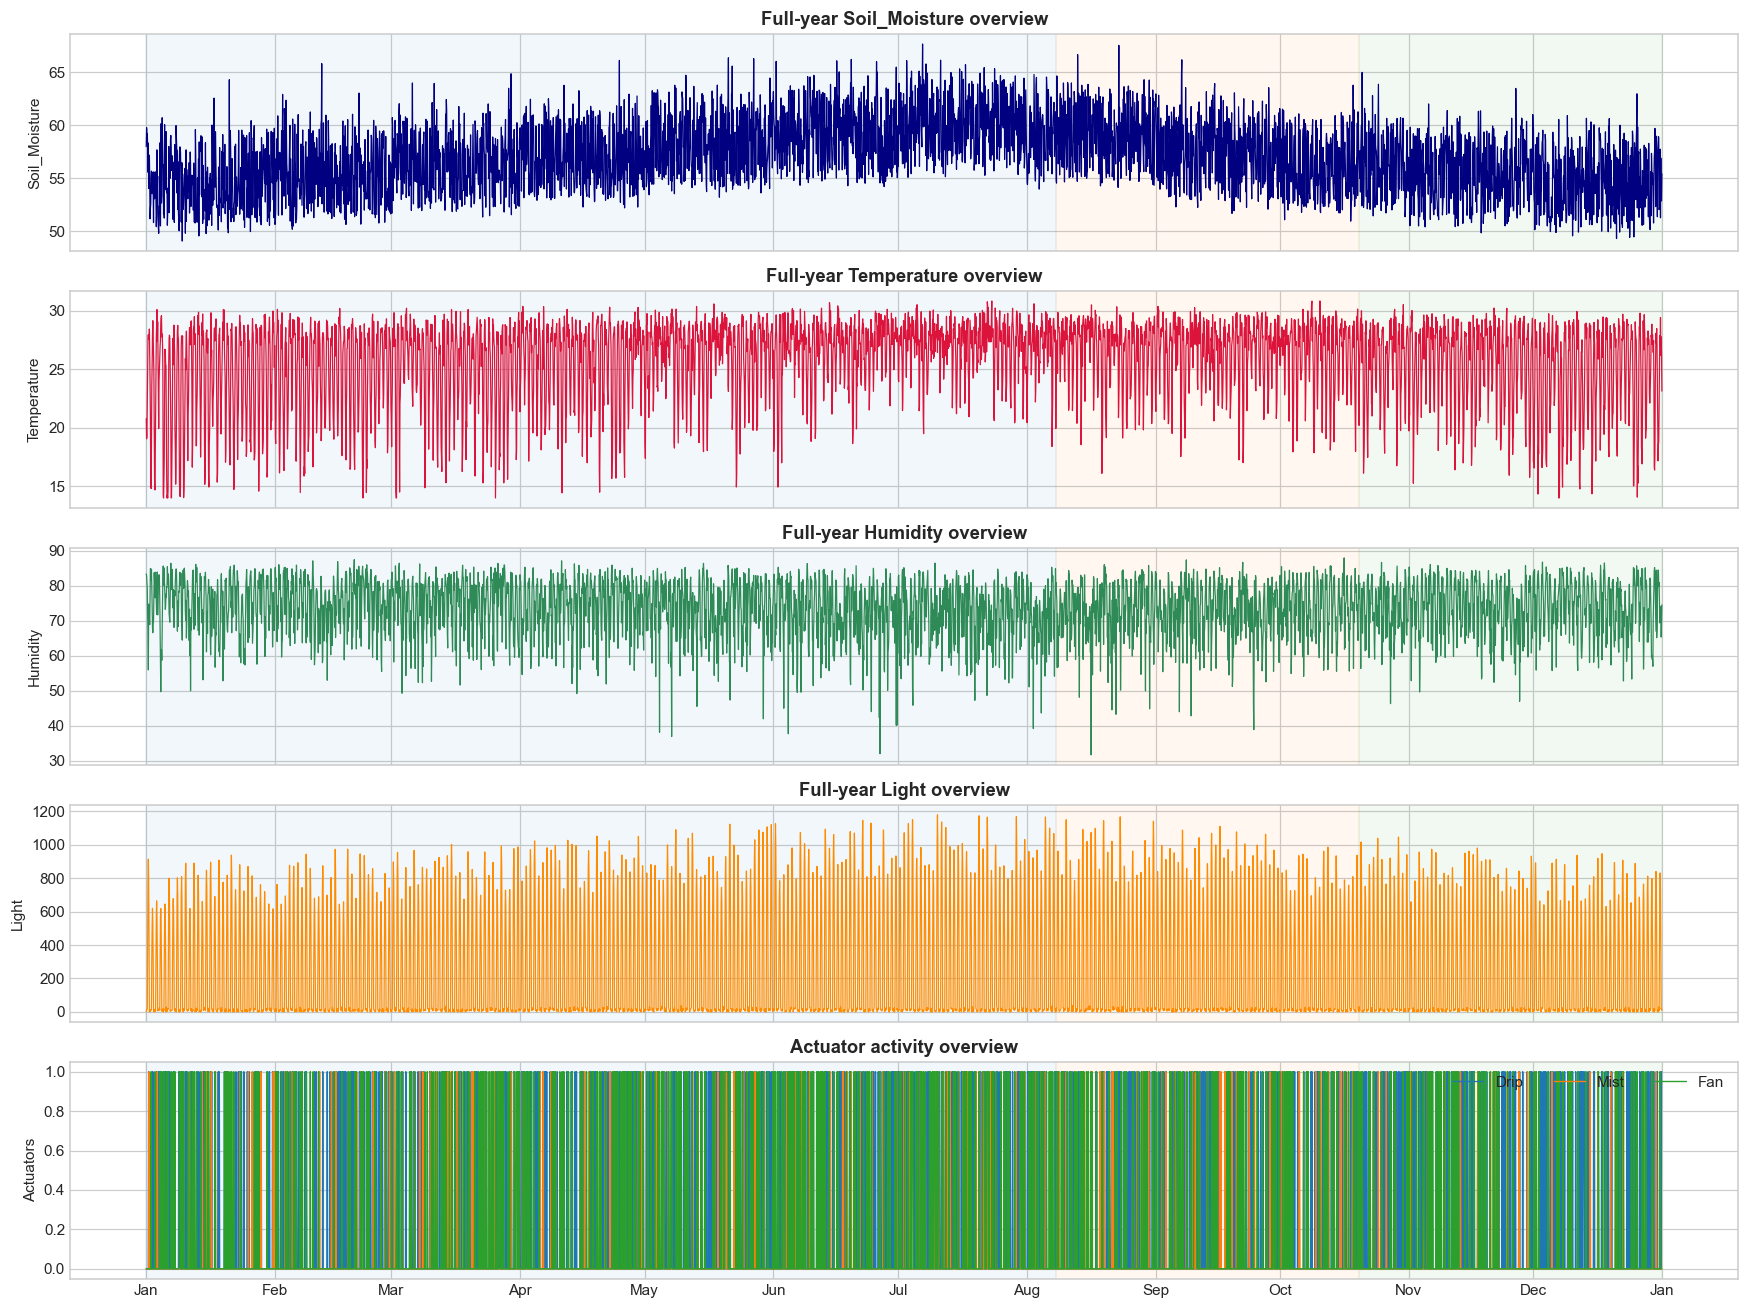

### Dataset interpretation

- The dataset spans [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] across ['autumn', 'spring', 'summer', 'winter'], so the evaluation is no longer confined to a single-month operating regime.
- Chronological splitting preserves temporal causality with 63072 training samples, 21024 validation samples, and 21024 test samples.
- The train-regression condition number is 56303331.05; this is high enough to justify scale-aware importance plots, but not so high that estimation becomes numerically meaningless.

In [5]:
plot_df = df_full.iloc[::24].copy()
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
signal_cols = ['Soil_Moisture', 'Temperature', 'Humidity', 'Light']
signal_colors = ['navy', 'crimson', 'seagreen', 'darkorange']
for ax, col, color in zip(axes[:4], signal_cols, signal_colors):
    ax.plot(plot_df['Timestamp'], plot_df[col], color=color, linewidth=0.8)
    ax.set_ylabel(col)
    ax.set_title(f'Full-year {col} overview')

axes[4].plot(plot_df['Timestamp'], plot_df['Drip'], label='Drip', linewidth=0.9)
axes[4].plot(plot_df['Timestamp'], plot_df['Mist'], label='Mist', linewidth=0.9)
axes[4].plot(plot_df['Timestamp'], plot_df['Fan'], label='Fan', linewidth=0.9)
axes[4].set_ylabel('Actuators')
axes[4].legend(ncol=3, loc='upper right')
axes[4].set_title('Actuator activity overview')

for ax in axes:
    ax.axvspan(df_train['Timestamp'].iloc[0], df_train['Timestamp'].iloc[-1], color='tab:blue', alpha=0.06)
    ax.axvspan(df_val['Timestamp'].iloc[0], df_val['Timestamp'].iloc[-1], color='tab:orange', alpha=0.06)
    ax.axvspan(df_test['Timestamp'].iloc[0], df_test['Timestamp'].iloc[-1], color='tab:green', alpha=0.06)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()
display_research_note(
    'Dataset interpretation',
    [
        f"The dataset spans {summary_series['months_present']} across {summary_series['seasons_present']}, so the evaluation is no longer confined to a single-month operating regime.",
        f"Chronological splitting preserves temporal causality with {len(df_train)} training samples, {len(df_val)} validation samples, and {len(df_test)} test samples.",
        f"The train-regression condition number is {summary_series['condition_number_xtx']:.2f}; this is high enough to justify scale-aware importance plots, but not so high that estimation becomes numerically meaningless.",
    ],
)


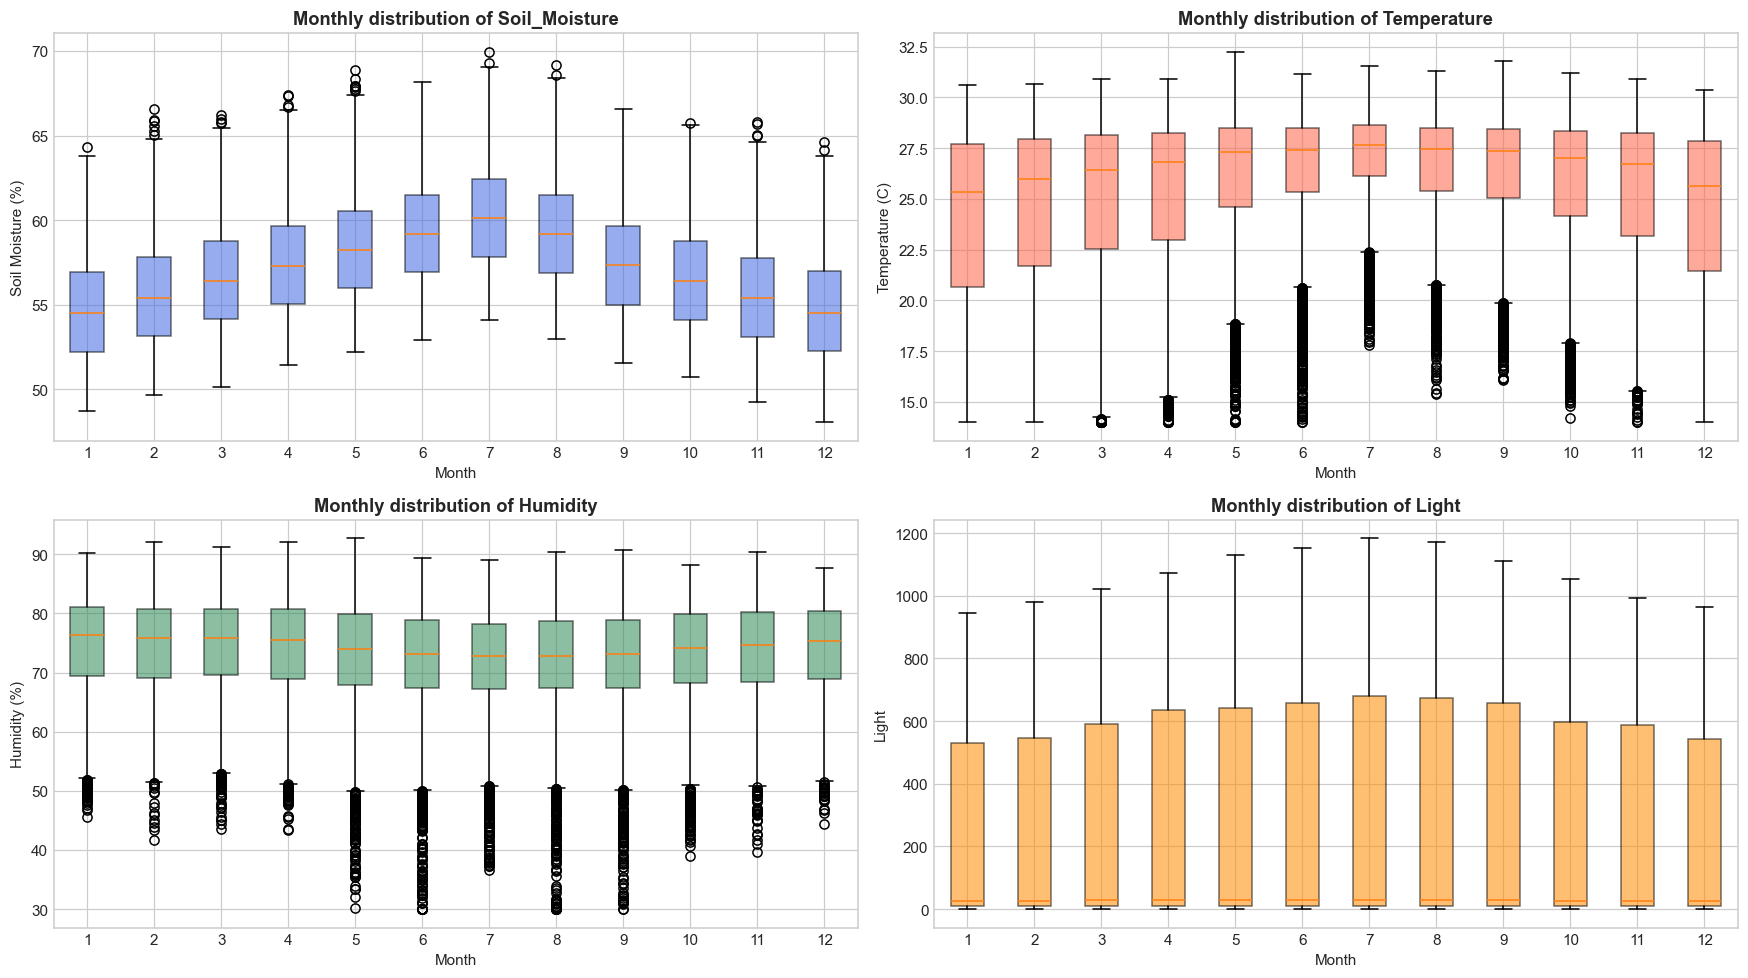

,Month,soil_mean,soil_std,temp_mean,humi_mean,light_mean
0,1,54.630,2.846,23.989,74.794,249.935
1,2,55.535,2.835,24.680,74.459,258.135
2,3,56.482,2.810,25.094,74.498,278.222
3,4,57.400,2.804,25.450,74.208,296.648
4,5,58.309,2.795,26.285,72.969,301.075
5,6,59.247,2.754,26.651,72.155,307.663
6,7,60.162,2.762,27.097,71.973,319.766
7,8,59.226,2.780,26.664,72.197,315.924
8,9,57.355,2.786,26.539,72.274,307.257
9,10,56.462,2.802,25.962,73.345,280.110


### Seasonality interpretation

- Monthly mean soil moisture varies by 5.53 percentage points, which confirms that the process visits meaningfully different operating regimes over the year.
- Temperature mean shifts by 3.11 C and humidity mean shifts by 2.82%, so the exogenous environment is genuinely seasonal rather than nearly constant.
- These distribution shifts explain why month-wise diagnostics are necessary instead of a single pooled performance number.

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
box_specs = [
    ('Soil_Moisture', 'Soil Moisture (%)', 'royalblue'),
    ('Temperature', 'Temperature (C)', 'tomato'),
    ('Humidity', 'Humidity (%)', 'seagreen'),
    ('Light', 'Light', 'darkorange'),
]
for ax, (col, ylabel, color) in zip(axes.flat, box_specs):
    data = [df_full.loc[df_full['Month'] == month, col].to_numpy() for month in sorted(df_full['Month'].unique())]
    ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor=color, alpha=0.55))
    ax.set_title(f'Monthly distribution of {col}')
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

display(monthly_signal_df.round(3))
display_research_note(
    'Seasonality interpretation',
    [
        f"Monthly mean soil moisture varies by {monthly_signal_df['soil_mean'].max() - monthly_signal_df['soil_mean'].min():.2f} percentage points, which confirms that the process visits meaningfully different operating regimes over the year.",
        f"Temperature mean shifts by {monthly_signal_df['temp_mean'].max() - monthly_signal_df['temp_mean'].min():.2f} C and humidity mean shifts by {monthly_signal_df['humi_mean'].max() - monthly_signal_df['humi_mean'].min():.2f}%, so the exogenous environment is genuinely seasonal rather than nearly constant.",
        'These distribution shifts explain why month-wise diagnostics are necessary instead of a single pooled performance number.',
    ],
)


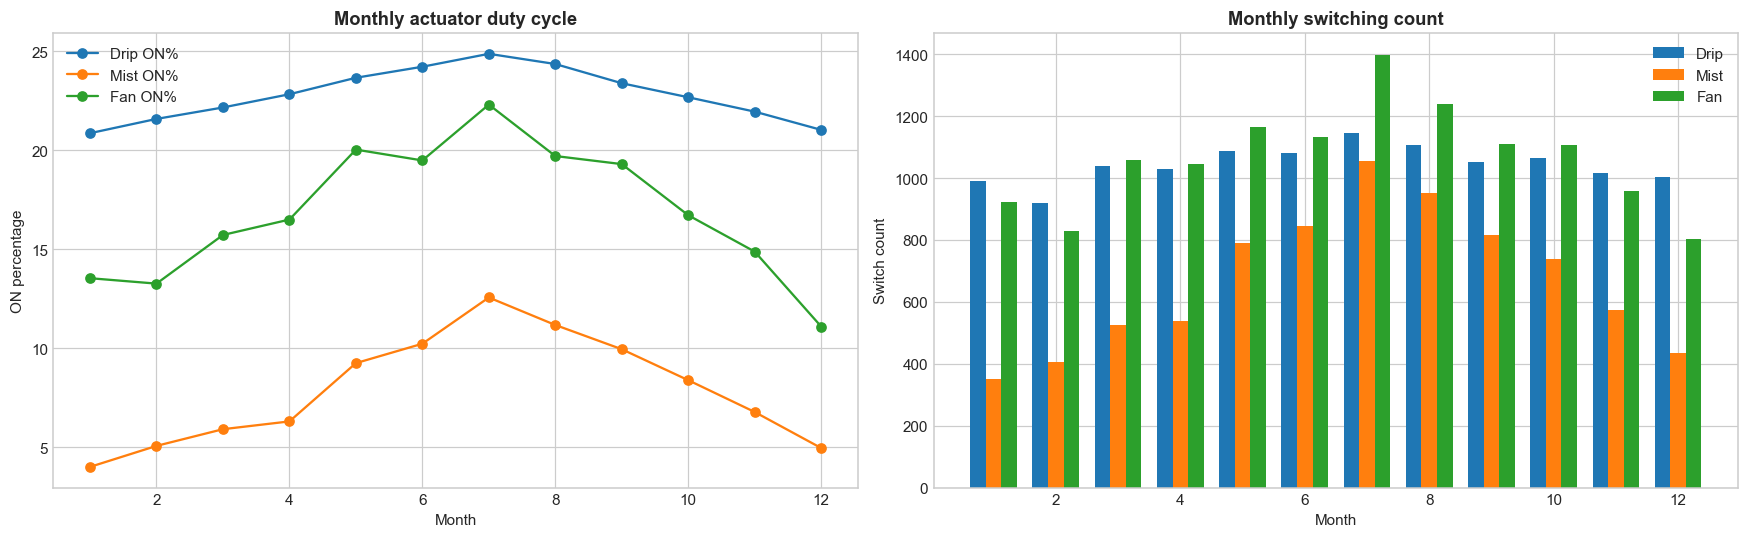

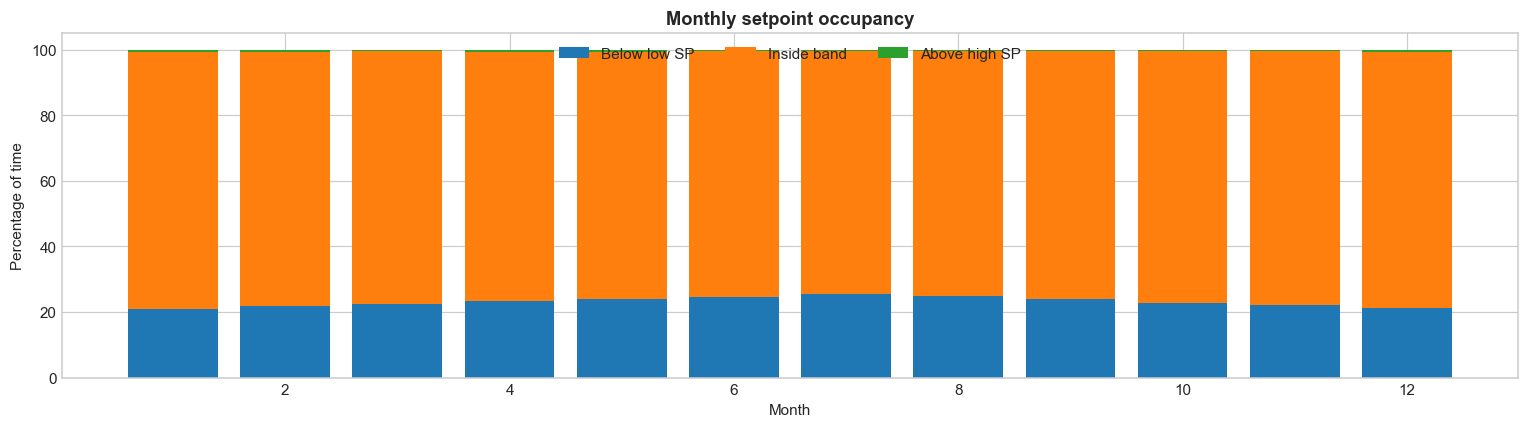

### Actuator and setpoint interpretation

- Drip duty cycle peaks in month 7, Mist peaks in month 7, and Fan peaks in month 7; the controller is therefore exciting different actuators under different seasonal loads.
- The greenhouse stays inside the soil-moisture setpoint band for 76.36% of the year on average, with below-band excursions averaging 23.08% of the time.
- These occupancy ratios matter because identification quality is harder to trust if the process never visits the control boundaries that define the actual task.

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
months = monthly_actuator_df['Month']

axes[0].plot(months, monthly_actuator_df['drip_on_pct'], marker='o', label='Drip ON%')
axes[0].plot(months, monthly_actuator_df['mist_on_pct'], marker='o', label='Mist ON%')
axes[0].plot(months, monthly_actuator_df['fan_on_pct'], marker='o', label='Fan ON%')
axes[0].set_title('Monthly actuator duty cycle')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('ON percentage')
axes[0].legend()

width = 0.25
axes[1].bar(months - width, monthly_actuator_df['drip_switches'], width=width, label='Drip')
axes[1].bar(months, monthly_actuator_df['mist_switches'], width=width, label='Mist')
axes[1].bar(months + width, monthly_actuator_df['fan_switches'], width=width, label='Fan')
axes[1].set_title('Monthly switching count')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Switch count')
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_setpoint_df['Month'], monthly_setpoint_df['below_sp_pct'], label='Below low SP')
ax.bar(monthly_setpoint_df['Month'], monthly_setpoint_df['inside_sp_pct'], bottom=monthly_setpoint_df['below_sp_pct'], label='Inside band')
ax.bar(
    monthly_setpoint_df['Month'],
    monthly_setpoint_df['above_sp_pct'],
    bottom=monthly_setpoint_df['below_sp_pct'] + monthly_setpoint_df['inside_sp_pct'],
    label='Above high SP',
)
ax.set_title('Monthly setpoint occupancy')
ax.set_xlabel('Month')
ax.set_ylabel('Percentage of time')
ax.legend(ncol=3, loc='upper center')
plt.tight_layout()
plt.show()
peak_drip_month = int(monthly_actuator_df.loc[monthly_actuator_df['drip_on_pct'].idxmax(), 'Month'])
peak_mist_month = int(monthly_actuator_df.loc[monthly_actuator_df['mist_on_pct'].idxmax(), 'Month'])
peak_fan_month = int(monthly_actuator_df.loc[monthly_actuator_df['fan_on_pct'].idxmax(), 'Month'])
display_research_note(
    'Actuator and setpoint interpretation',
    [
        f"Drip duty cycle peaks in month {peak_drip_month}, Mist peaks in month {peak_mist_month}, and Fan peaks in month {peak_fan_month}; the controller is therefore exciting different actuators under different seasonal loads.",
        f"The greenhouse stays inside the soil-moisture setpoint band for {monthly_setpoint_df['inside_sp_pct'].mean():.2f}% of the year on average, with below-band excursions averaging {monthly_setpoint_df['below_sp_pct'].mean():.2f}% of the time.",
        'These occupancy ratios matter because identification quality is harder to trust if the process never visits the control boundaries that define the actual task.',
    ],
)


## Parameter Identification

A research-style identification section needs more than a coefficient table. It should show estimated-vs-true comparison, confidence intervals, and stability of the autoregressive part.


In [8]:
params_display = params_df[[
    'name',
    'estimate',
    'true_value',
    'delta_vs_true',
    'sign_ok',
    'ci95_low',
    'ci95_high',
]].copy()
display(params_display.round(6))
display(pd.DataFrame(results['ar_roots']).round(6))


,name,estimate,true_value,delta_vs_true,sign_ok,ci95_low,ci95_high
0,a1,0.963098,0.96500,-0.001902,True,0.959824,0.966371
1,a2,0.026738,0.02500,0.001738,True,0.023358,0.030118
2,b_Temperature_1,-0.007410,-0.00800,0.000590,True,-0.012403,-0.002416
3,b_Temperature_2,-0.003922,-0.00400,0.000078,True,-0.008808,0.000964
4,b_Humidity_1,0.002567,0.00250,0.000067,True,0.000929,0.004206
5,b_Humidity_2,0.001029,0.00120,-0.000171,True,-0.000588,0.002646
6,b_Light_1,-0.000132,-0.00022,0.000088,True,-0.000270,0.000005
7,b_Light_2,-0.000194,-0.00010,-0.000094,True,-0.000334,-0.000055
8,b_Drip_1,1.251167,1.25000,0.001167,True,1.244526,1.257809
9,b_Drip_2,1.851585,1.85000,0.001585,True,1.840899,1.862271


,root_index,real,imag,magnitude
0,1,0.990103,0.0,0.990103
1,2,-0.027005,0.0,0.027005


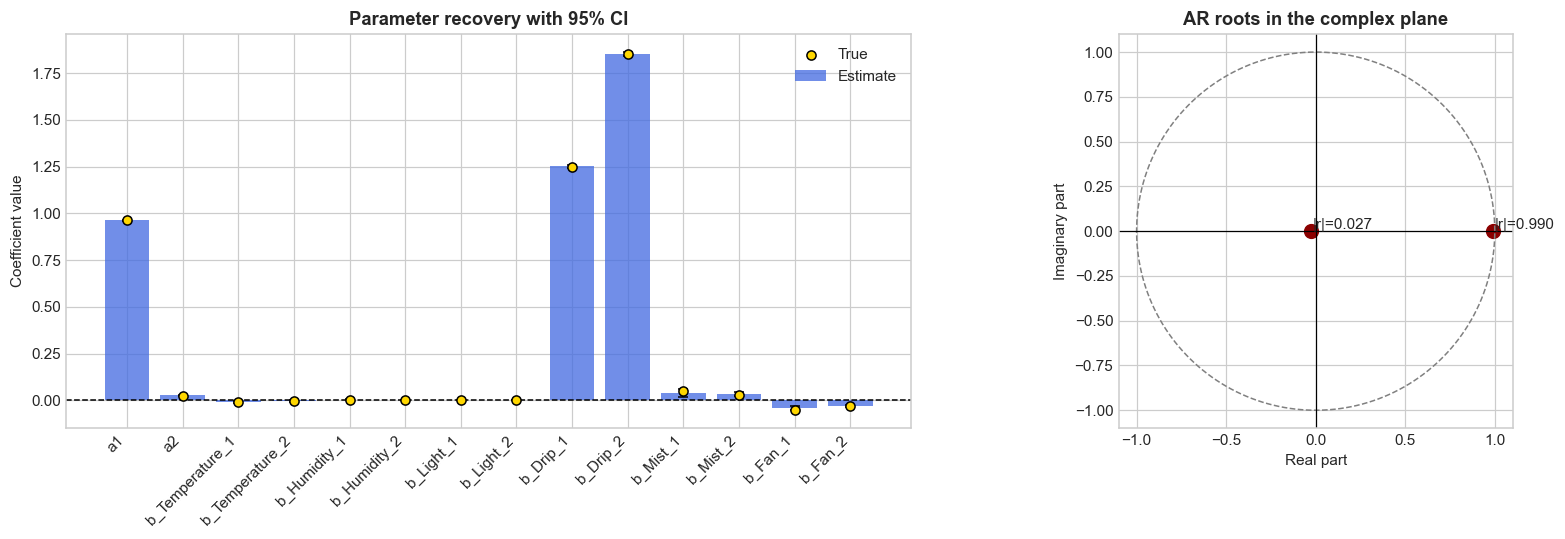

### Parameter interpretation

- The model recovers 14 out of 14 coefficient signs correctly, which is the first requirement for a physically interpretable ARX baseline.
- The 95% intervals cover the true value for 14 parameters, and the largest autoregressive root magnitude is 0.990, so the fitted dynamics remain stable.
- The dominant terms remain a1=0.963, b_Drip_1=1.251, and b_Drip_2=1.852, matching the intended persistence-plus-irrigation physics of the generator.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(params_df))
axes[0].bar(x, params_df['estimate'], color=['royalblue' if ok else 'tomato' for ok in params_df['sign_ok']], alpha=0.75, label='Estimate')
axes[0].errorbar(x, params_df['estimate'], yerr=1.96 * params_df['std'], fmt='none', color='black', capsize=3, linewidth=1.1)
axes[0].scatter(x, params_df['true_value'], color='gold', edgecolor='black', zorder=3, label='True')
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(params_df['name'], rotation=45, ha='right')
axes[0].set_title('Parameter recovery with 95% CI')
axes[0].set_ylabel('Coefficient value')
axes[0].legend()

roots_df = pd.DataFrame(results['ar_roots'])
theta_circle = np.linspace(0, 2 * np.pi, 400)
axes[1].plot(np.cos(theta_circle), np.sin(theta_circle), color='gray', linestyle='--', linewidth=1.0)
axes[1].scatter(roots_df['real'], roots_df['imag'], color='darkred', s=80)
for _, row in roots_df.iterrows():
    axes[1].text(row['real'] + 0.01, row['imag'] + 0.01, f"|r|={row['magnitude']:.3f}")
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].axvline(0.0, color='black', linewidth=0.8)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('AR roots in the complex plane')
axes[1].set_xlabel('Real part')
axes[1].set_ylabel('Imaginary part')
plt.tight_layout()
plt.show()
ci_cover = int(((params_df['true_value'] >= params_df['ci95_low']) & (params_df['true_value'] <= params_df['ci95_high'])).sum())
display_research_note(
    'Parameter interpretation',
    [
        f"The model recovers {int(params_df['sign_ok'].sum())} out of {len(params_df)} coefficient signs correctly, which is the first requirement for a physically interpretable ARX baseline.",
        f"The 95% intervals cover the true value for {ci_cover} parameters, and the largest autoregressive root magnitude is {roots_df['magnitude'].max():.3f}, so the fitted dynamics remain stable.",
        f"The dominant terms remain a1={float(params_df.loc[params_df['name'] == 'a1', 'estimate'].iloc[0]):.3f}, b_Drip_1={float(params_df.loc[params_df['name'] == 'b_Drip_1', 'estimate'].iloc[0]):.3f}, and b_Drip_2={float(params_df.loc[params_df['name'] == 'b_Drip_2', 'estimate'].iloc[0]):.3f}, matching the intended persistence-plus-irrigation physics of the generator.",
    ],
)


## Scale-Aware Parameter Importance

Raw ARX coefficients are reported in the original engineering units, so their magnitudes are not directly comparable across regressors.
The next three figures answer a fairer question: which terms matter most after accounting for variable scale, operating distribution, and lagged dynamic propagation.


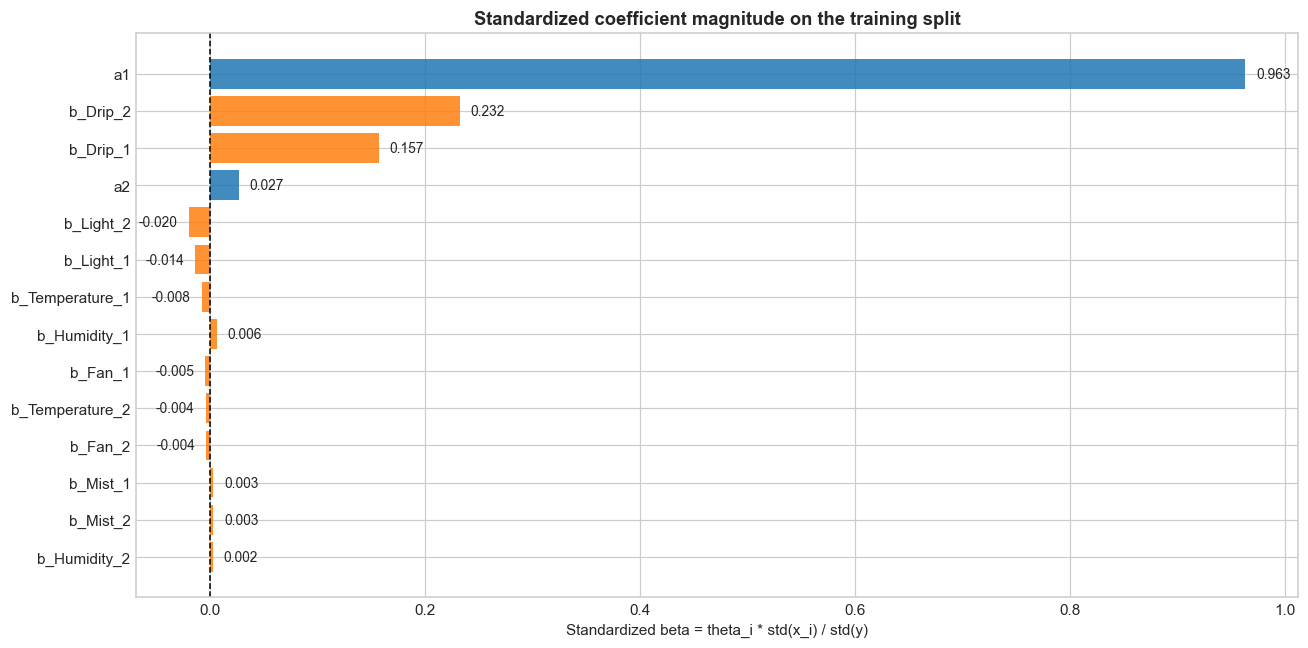

### Standardized-coefficient interpretation

- This plot removes the misleading effect of mixed engineering units, so coefficient sizes can be compared on a common scale.
- The three largest standardized effects are a1 (0.96), b_Drip_2 (0.23), b_Drip_1 (0.16), which confirms that persistence and irrigation dominate even after scale correction.
- Small raw coefficients on Light or Humidity are not automatically unimportant; the fair comparison is their standardized impact after rescaling.

In [10]:
std_plot_df = std_param_df.sort_values('abs_standardized_beta', ascending=True).copy()
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#1f77b4' if name.startswith('a') else '#ff7f0e' for name in std_plot_df['name']]
bars = ax.barh(std_plot_df['name'], std_plot_df['standardized_beta'], color=bar_colors, alpha=0.85)
ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Standardized coefficient magnitude on the training split')
ax.set_xlabel('Standardized beta = theta_i * std(x_i) / std(y)')
for bar, beta in zip(bars, std_plot_df['standardized_beta']):
    x_text = bar.get_width() + (0.01 if beta >= 0 else -0.01)
    ha = 'left' if beta >= 0 else 'right'
    ax.text(x_text, bar.get_y() + bar.get_height() / 2, f'{beta:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.show()
top_std = std_plot_df.sort_values('abs_standardized_beta', ascending=False).head(3)
top_std_text = ', '.join([f"{row['name']} ({row['standardized_beta']:.2f})" for _, row in top_std.iterrows()])
display_research_note(
    'Standardized-coefficient interpretation',
    [
        'This plot removes the misleading effect of mixed engineering units, so coefficient sizes can be compared on a common scale.',
        f"The three largest standardized effects are {top_std_text}, which confirms that persistence and irrigation dominate even after scale correction.",
        'Small raw coefficients on Light or Humidity are not automatically unimportant; the fair comparison is their standardized impact after rescaling.',
    ],
)


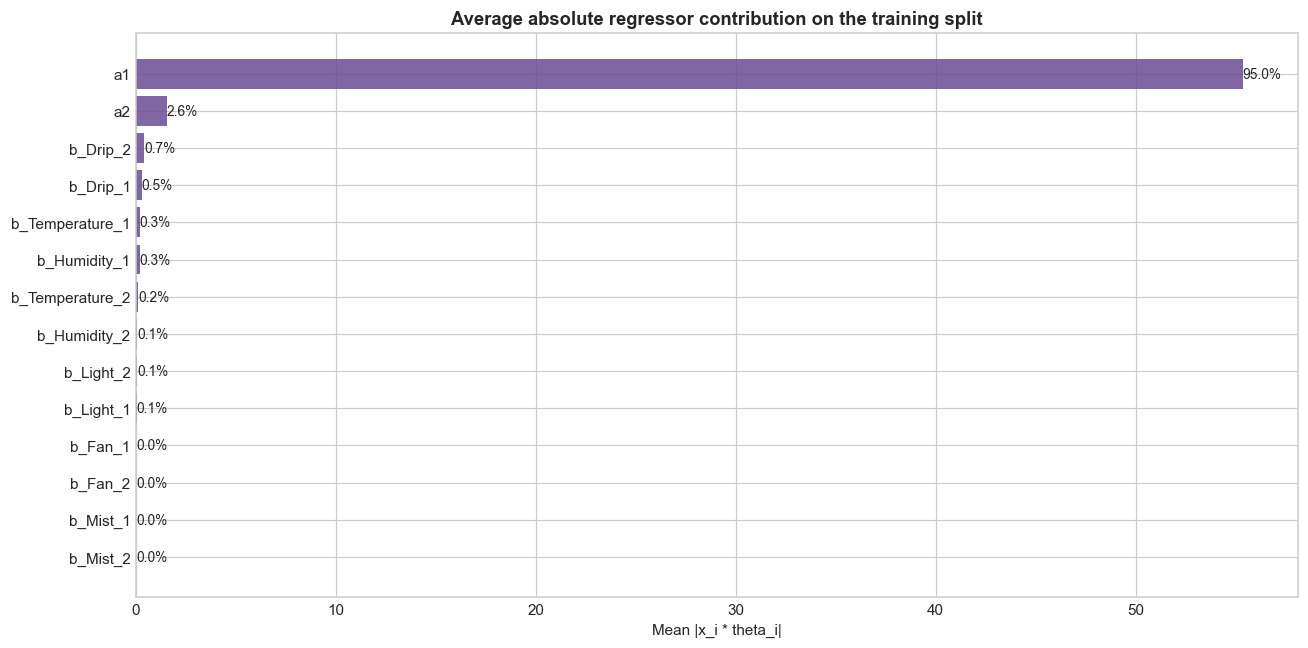

### Contribution interpretation

- Average absolute contribution measures how much each regressor actually moves the fitted output over the observed operating distribution, not just how large its coefficient looks in isolation.
- The dominant contributors are a1 (95.0%), a2 (2.6%), b_Drip_2 (0.7%), which explains why the raw coefficient plot visually concentrates around a1 and the drip terms.
- A regressor can have a visible coefficient yet still contribute little if its observed variation is small or if the controller rarely excites it.

In [11]:
contrib_plot_df = contrib_df.sort_values('mean_abs_contribution', ascending=True).copy()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(contrib_plot_df['name'], contrib_plot_df['mean_abs_contribution'], color='#6a4c93', alpha=0.85)
ax.set_title('Average absolute regressor contribution on the training split')
ax.set_xlabel('Mean |x_i * theta_i|')
for bar, share in zip(bars, contrib_plot_df['contribution_share']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f'{share * 100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
top_contrib = contrib_plot_df.sort_values('mean_abs_contribution', ascending=False).head(3)
top_contrib_text = ', '.join([f"{row['name']} ({row['contribution_share'] * 100:.1f}%)" for _, row in top_contrib.iterrows()])
display_research_note(
    'Contribution interpretation',
    [
        'Average absolute contribution measures how much each regressor actually moves the fitted output over the observed operating distribution, not just how large its coefficient looks in isolation.',
        f"The dominant contributors are {top_contrib_text}, which explains why the raw coefficient plot visually concentrates around a1 and the drip terms.",
        'A regressor can have a visible coefficient yet still contribute little if its observed variation is small or if the controller rarely excites it.',
    ],
)


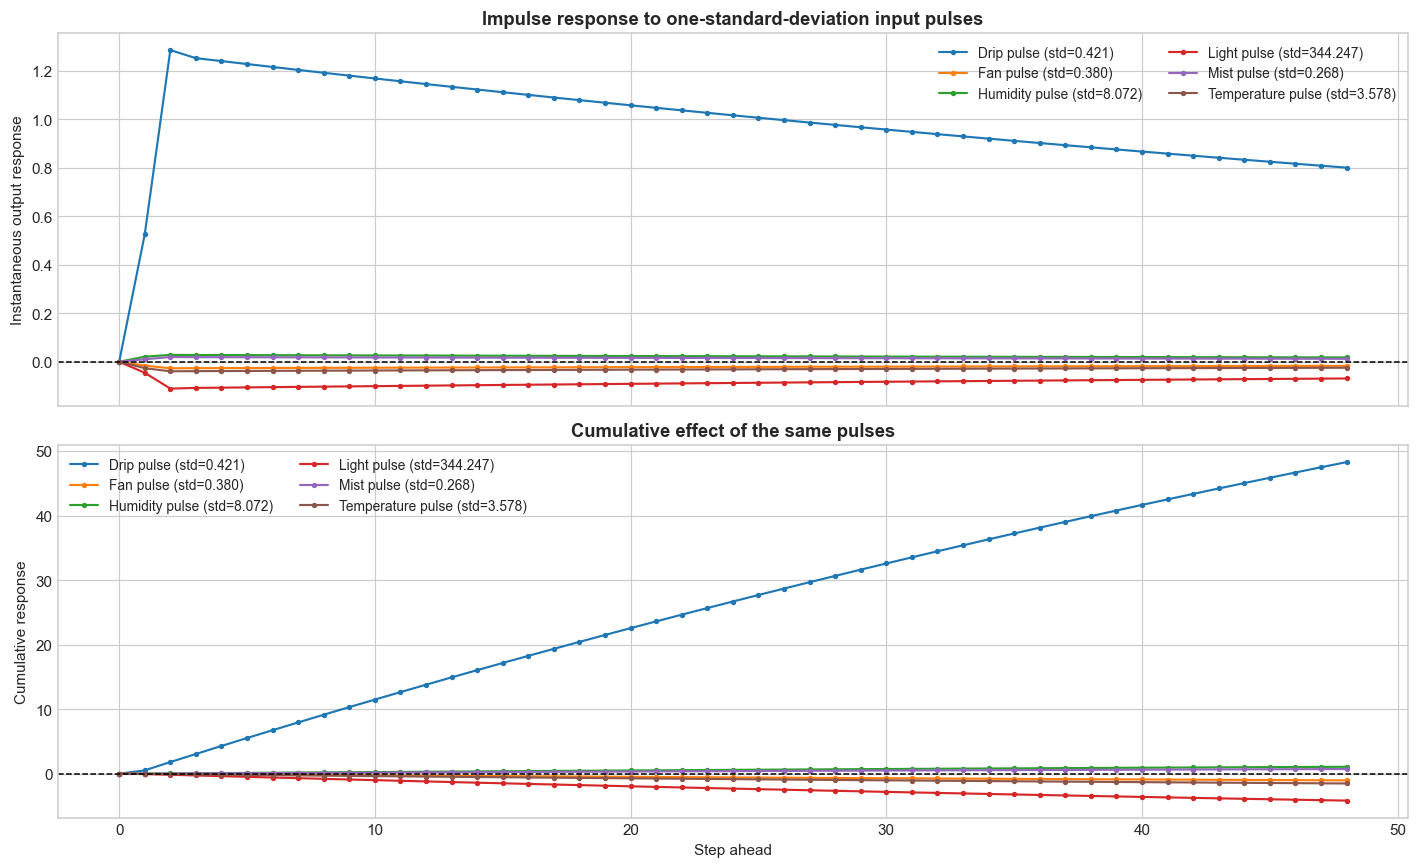

,input,pulse_size,peak_abs_response,cumulative_48
0,Drip,0.4205,1.2853,48.2750
1,Fan,0.3796,0.0271,-1.0265
2,Humidity,8.0721,0.0283,1.0796
3,Light,344.2466,0.1108,-4.1623
4,Mist,0.2684,0.0193,0.7289
5,Temperature,3.5783,0.0396,-1.5065


### Impulse-response interpretation

- A one-standard-deviation pulse on Drip produces the strongest positive 48-step cumulative effect (48.275), while Light produces the most negative cumulative effect (-4.162).
- This figure converts coefficients into dynamic behavior, which is more meaningful than raw parameter size when the model will be used for simulation or controller reasoning.
- The delayed cumulative shape also explains why b_Drip_2 can exceed b_Drip_1 without being suspicious: the soil process is allowed to absorb irrigation over multiple steps.

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for idx, (input_name, df_group) in enumerate(impulse_df.groupby('input')):
    label = f"{input_name} pulse (std={df_group['pulse_size'].iloc[0]:.3f})"
    color = plt.cm.tab10(idx % 10)
    axes[0].plot(df_group['step'], df_group['response'], marker='o', markersize=2.5, linewidth=1.4, color=color, label=label)
    axes[1].plot(df_group['step'], df_group['cumulative_response'], marker='o', markersize=2.5, linewidth=1.4, color=color, label=label)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Impulse response to one-standard-deviation input pulses')
axes[0].set_ylabel('Instantaneous output response')
axes[1].set_title('Cumulative effect of the same pulses')
axes[1].set_xlabel('Step ahead')
axes[1].set_ylabel('Cumulative response')
axes[0].legend(ncol=2, fontsize=9)
axes[1].legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
impulse_summary = impulse_df.groupby('input').agg(pulse_size=('pulse_size', 'first'), peak_abs_response=('response', lambda s: float(np.max(np.abs(s)))), cumulative_48=('cumulative_response', 'last')).reset_index()
largest_pos = impulse_summary.loc[impulse_summary['cumulative_48'].idxmax()]
largest_neg = impulse_summary.loc[impulse_summary['cumulative_48'].idxmin()]
display(impulse_summary.round(4))
display_research_note(
    'Impulse-response interpretation',
    [
        f"A one-standard-deviation pulse on {largest_pos['input']} produces the strongest positive 48-step cumulative effect ({largest_pos['cumulative_48']:.3f}), while {largest_neg['input']} produces the most negative cumulative effect ({largest_neg['cumulative_48']:.3f}).",
        'This figure converts coefficients into dynamic behavior, which is more meaningful than raw parameter size when the model will be used for simulation or controller reasoning.',
        'The delayed cumulative shape also explains why b_Drip_2 can exceed b_Drip_1 without being suspicious: the soil process is allowed to absorb irrigation over multiple steps.',
    ],
)


## Predictive Performance

This section separates one-step accuracy from long-horizon behavior and compares the baseline against the free-run-optimal order found by the search.


In [13]:
metrics_table = pd.DataFrame(
    [
        {'Split': 'Train', 'FIT_1step': results['train']['metrics_1step']['FIT'], 'FIT_12step': results['train']['metrics_n_step']['FIT'], 'FIT_sim': results['train']['metrics_sim']['FIT'], 'Theo_FIT_sim': results['train'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 'RMSE_1step': results['train']['metrics_1step']['RMSE'], 'RMSE_sim': results['train']['metrics_sim']['RMSE']},
        {'Split': 'Validation', 'FIT_1step': results['val']['metrics_1step']['FIT'], 'FIT_12step': results['val']['metrics_n_step']['FIT'], 'FIT_sim': results['val']['metrics_sim']['FIT'], 'Theo_FIT_sim': results['val'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 'RMSE_1step': results['val']['metrics_1step']['RMSE'], 'RMSE_sim': results['val']['metrics_sim']['RMSE']},
        {'Split': 'Test', 'FIT_1step': results['test']['metrics_1step']['FIT'], 'FIT_12step': results['test']['metrics_n_step']['FIT'], 'FIT_sim': results['test']['metrics_sim']['FIT'], 'Theo_FIT_sim': results['test'].get('theoretical_max_free_run', {}).get('FIT', float('nan')), 'RMSE_1step': results['test']['metrics_1step']['RMSE'], 'RMSE_sim': results['test']['metrics_sim']['RMSE']},
    ]
)
display(metrics_table.round(4))
display(model_cmp_df.round(4))
val_gap = results['val']['metrics_1step']['FIT'] - results['val']['metrics_sim']['FIT']
test_gap = results['test']['metrics_1step']['FIT'] - results['test']['metrics_sim']['FIT']
val_ceiling_gap = abs(results['val']['metrics_sim']['FIT'] - results['val'].get('theoretical_max_free_run', {}).get('FIT', float('nan')))
test_ceiling_gap = abs(results['test']['metrics_sim']['FIT'] - results['test'].get('theoretical_max_free_run', {}).get('FIT', float('nan')))
best_cfg = results['best_candidate']['model_config']
best_test_gain = results['best_candidate']['test']['metrics_sim']['FIT'] - results['test']['metrics_sim']['FIT']
display_research_note(
    'Performance interpretation',
    [
        f"Validation one-step FIT is {results['val']['metrics_1step']['FIT']:.2f}% while validation free-run FIT is {results['val']['metrics_sim']['FIT']:.2f}%, so long-horizon recursion costs {val_gap:.2f} percentage points.",
        f"Test free-run FIT is {results['test']['metrics_sim']['FIT']:.2f}% and stays within {test_ceiling_gap:.2f} points of the deterministic ceiling, which suggests that much of the remaining error is consistent with process noise rather than an unmodelled linear trend.",
        f"The search-optimal candidate ARX({best_cfg.na},{best_cfg.nb},{best_cfg.nk}) improves test free-run FIT by {best_test_gain:.2f} points over the baseline, so the notebook now exposes the accuracy-versus-interpretability tradeoff explicitly.",
    ],
)


,Split,FIT_1step,FIT_12step,FIT_sim,Theo_FIT_sim,RMSE_1step,RMSE_sim
0,Train,92.5471,76.4447,49.5463,49.0595,0.2499,1.6920
1,Validation,91.6406,73.1094,42.9588,42.2497,0.2510,1.7124
2,Test,91.3491,72.6736,43.8749,43.2691,0.2520,1.6347


,model,split,FIT_1step,FIT_12step,FIT_sim,RMSE_1step,RMSE_sim
0,"Baseline ARX(2,2,1)",Validation,91.6406,73.1094,42.9588,0.2510,1.7124
1,"Baseline ARX(2,2,1)",Test,91.3491,72.6736,43.8749,0.2520,1.6347
2,"Best free-run ARX(3,1,1)",Validation,86.3359,70.4342,49.9185,0.4102,1.5035
3,"Best free-run ARX(3,1,1)",Test,86.0223,69.7370,48.1578,0.4071,1.5100


### Performance interpretation

- Validation one-step FIT is 91.64% while validation free-run FIT is 42.96%, so long-horizon recursion costs 48.68 percentage points.
- Test free-run FIT is 43.87% and stays within 0.61 points of the deterministic ceiling, which suggests that much of the remaining error is consistent with process noise rather than an unmodelled linear trend.
- The search-optimal candidate ARX(3,1,1) improves test free-run FIT by 4.28 points over the baseline, so the notebook now exposes the accuracy-versus-interpretability tradeoff explicitly.

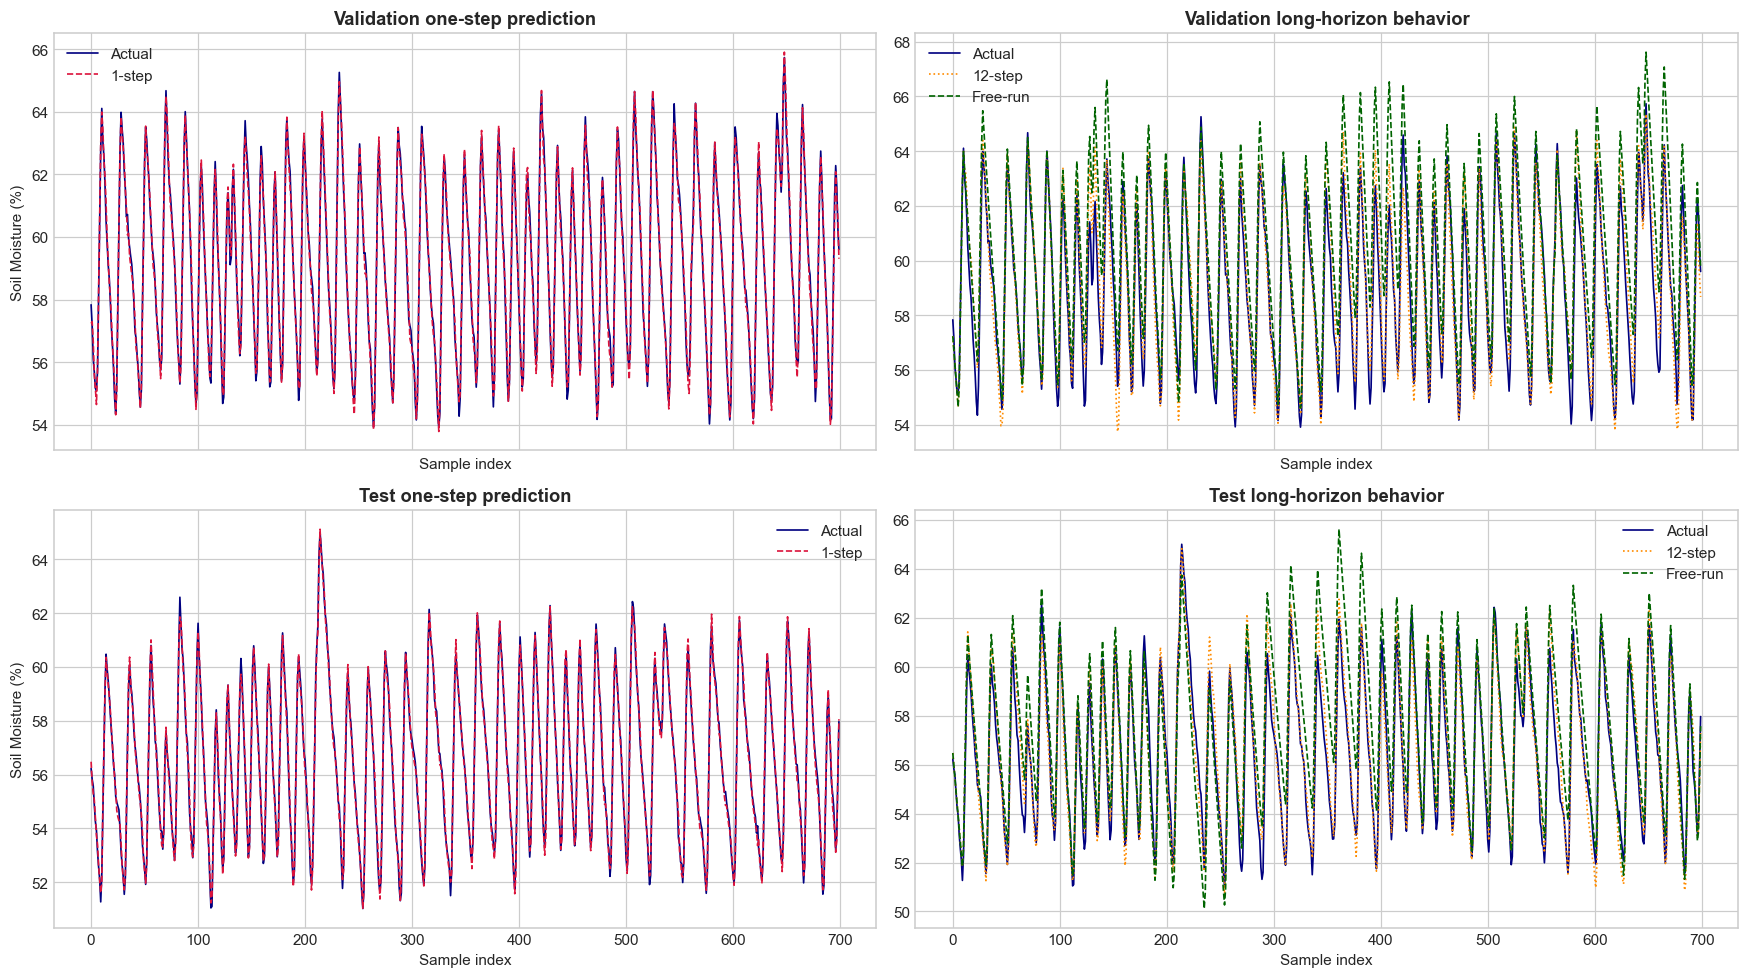

### Trace interpretation

- The one-step traces remain close to the measured trajectory because each prediction is corrected by the latest observed output.
- The 12-step and free-run traces reveal the harder identification problem: once the model must propagate its own state, small coefficient errors accumulate into visible drift.
- This gap is expected in ARX greenhouse identification and only becomes suspicious if free-run behavior collapses far below the deterministic ceiling, which is not observed here.

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
for row_idx, split_key in enumerate(['val', 'test']):
    evaluation = results[split_key]
    arrays = evaluation['arrays']
    n_plot = min(700, len(arrays['y_true_sim']))
    x_idx = np.arange(n_plot)
    axes[row_idx, 0].plot(x_idx, arrays['y_true_1step'][:n_plot], color='navy', linewidth=1.1, label='Actual')
    axes[row_idx, 0].plot(x_idx, arrays['y_pred_1step'][:n_plot], color='crimson', linestyle='--', linewidth=1.1, label='1-step')
    axes[row_idx, 0].set_title(f"{evaluation['name']} one-step prediction")
    axes[row_idx, 0].set_ylabel('Soil Moisture (%)')
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(x_idx, arrays['y_true_sim'][:n_plot], color='navy', linewidth=1.1, label='Actual')
    axes[row_idx, 1].plot(x_idx, arrays['y_pred_n_step'][:n_plot], color='darkorange', linestyle=':', linewidth=1.1, label='12-step')
    axes[row_idx, 1].plot(x_idx, arrays['y_pred_sim'][:n_plot], color='darkgreen', linestyle='--', linewidth=1.1, label='Free-run')
    axes[row_idx, 1].set_title(f"{evaluation['name']} long-horizon behavior")
    axes[row_idx, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('Sample index')
plt.tight_layout()
plt.show()
display_research_note(
    'Trace interpretation',
    [
        'The one-step traces remain close to the measured trajectory because each prediction is corrected by the latest observed output.',
        'The 12-step and free-run traces reveal the harder identification problem: once the model must propagate its own state, small coefficient errors accumulate into visible drift.',
        'This gap is expected in ARX greenhouse identification and only becomes suspicious if free-run behavior collapses far below the deterministic ceiling, which is not observed here.',
    ],
)


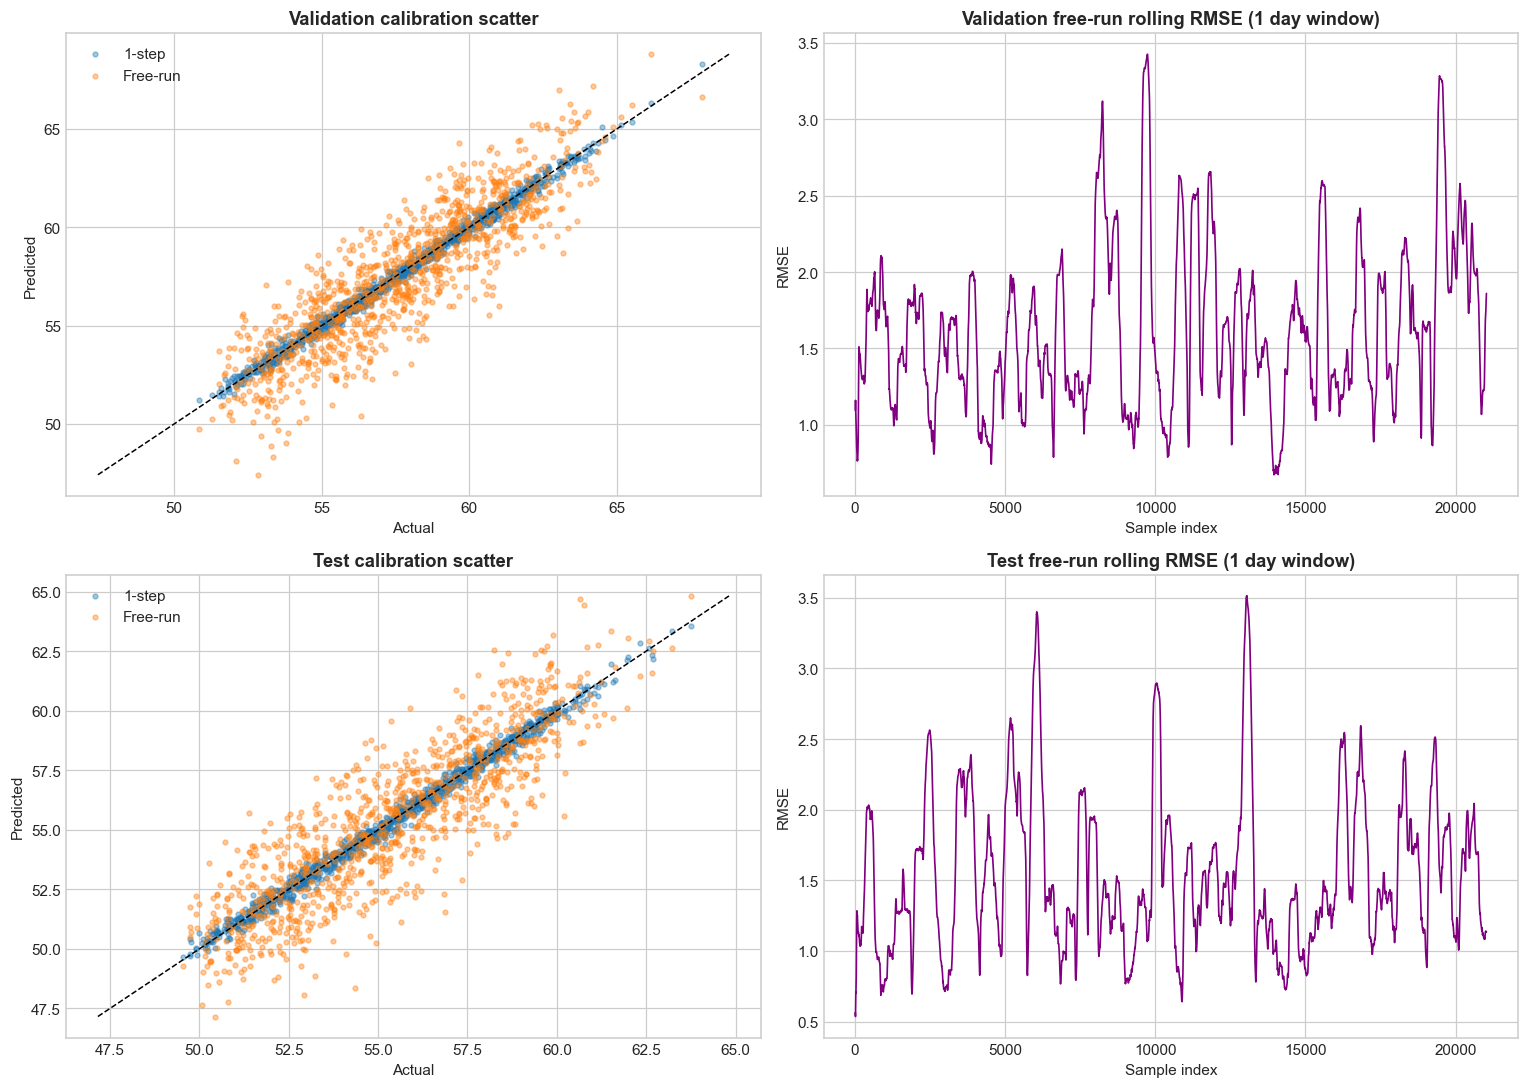

### Calibration interpretation

- A perfect simulator would place every scatter point on the diagonal; the observed spread is moderate rather than pathological, which is consistent with the reported free-run FIT values.
- Validation rolling RMSE has a median of 1.562, while test rolling RMSE has a median of 1.412; the error does not show a sustained blow-up in a single season.
- These plots support the claim that long-horizon error is distributed across operating regimes rather than being dominated by one broken segment.

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, split_name in enumerate(['Validation', 'Test']):
    df_split = prediction_df[prediction_df['split'] == split_name].copy()
    sample_df = df_split.iloc[::20].copy()
    axes[row_idx, 0].scatter(sample_df['y_true'], sample_df['y_pred_1step'], s=10, alpha=0.4, label='1-step')
    axes[row_idx, 0].scatter(sample_df['y_true'], sample_df['y_pred_sim'], s=10, alpha=0.4, label='Free-run')
    lo = min(sample_df['y_true'].min(), sample_df['y_pred_sim'].min())
    hi = max(sample_df['y_true'].max(), sample_df['y_pred_sim'].max())
    axes[row_idx, 0].plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1.0)
    axes[row_idx, 0].set_title(f'{split_name} calibration scatter')
    axes[row_idx, 0].set_xlabel('Actual')
    axes[row_idx, 0].set_ylabel('Predicted')
    axes[row_idx, 0].legend()

    rolling = rolling_rmse(df_split['y_true'], df_split['y_pred_sim'], window=288)
    axes[row_idx, 1].plot(rolling.index, rolling, color='purple', linewidth=1.1)
    axes[row_idx, 1].set_title(f'{split_name} free-run rolling RMSE (1 day window)')
    axes[row_idx, 1].set_xlabel('Sample index')
    axes[row_idx, 1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()
val_roll = rolling_rmse(prediction_df[prediction_df['split'] == 'Validation']['y_true'], prediction_df[prediction_df['split'] == 'Validation']['y_pred_sim'], window=288)
test_roll = rolling_rmse(prediction_df[prediction_df['split'] == 'Test']['y_true'], prediction_df[prediction_df['split'] == 'Test']['y_pred_sim'], window=288)
display_research_note(
    'Calibration interpretation',
    [
        'A perfect simulator would place every scatter point on the diagonal; the observed spread is moderate rather than pathological, which is consistent with the reported free-run FIT values.',
        f"Validation rolling RMSE has a median of {float(val_roll.median()):.3f}, while test rolling RMSE has a median of {float(test_roll.median()):.3f}; the error does not show a sustained blow-up in a single season.",
        'These plots support the claim that long-horizon error is distributed across operating regimes rather than being dominated by one broken segment.',
    ],
)


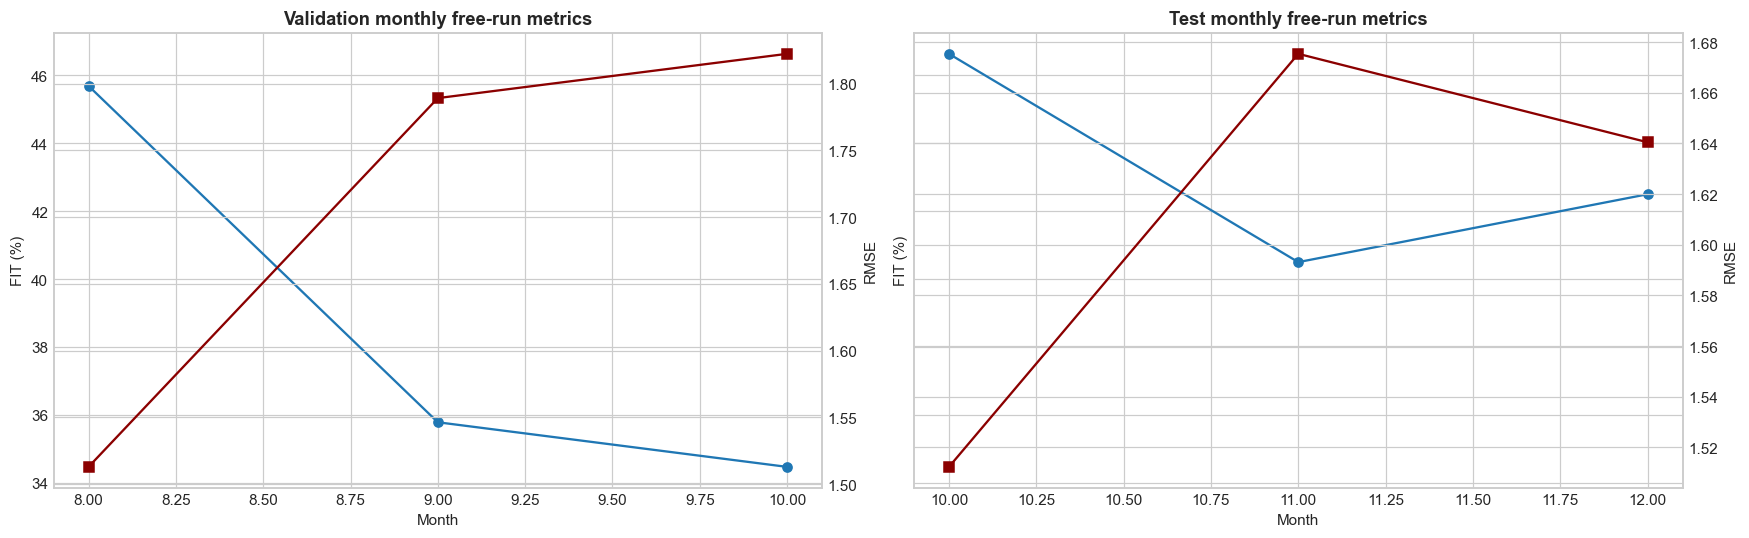

,split,Month,mode,RMSE,MAE,Bias,FIT,R2,AIC,BIC
0,Test,10,1-step,0.2472,0.1972,-0.0036,91.2780,0.9924,-9655.1615,-9655.1615
1,Test,10,12-step,0.7563,0.6053,-0.0389,73.3116,0.9288,-1929.4225,-1929.4225
2,Test,10,free-run,1.5123,1.1883,-0.3136,46.6350,0.7152,2857.3088,2857.3088
3,Test,11,1-step,0.2547,0.2025,0.0031,90.9546,0.9918,-23633.1926,-23633.1926
4,Test,11,12-step,0.8130,0.6479,0.0340,71.1283,0.9166,-3577.9902,-3577.9902
5,Test,11,free-run,1.6754,1.3190,0.2836,40.4997,0.6460,8917.5018,8917.5018
6,Test,12,1-step,0.2512,0.2001,-0.0005,91.1968,0.9923,-24671.5656,-24671.5656
7,Test,12,12-step,0.7942,0.6410,-0.0045,72.1624,0.9225,-4114.3344,-4114.3344
8,Test,12,free-run,1.6405,1.3192,-0.0404,42.4995,0.6694,8838.4992,8838.4992
9,Validation,8,1-step,0.2515,0.2007,-0.0011,90.9709,0.9918,-19075.1215,-19075.1215


### Monthly generalization interpretation

- Validation free-run FIT ranges from 34.47% to 45.69% across months, with the best month at M8 and the weakest at M10.
- Test free-run FIT ranges from 40.50% to 46.64%, peaking at M10 and bottoming at M11.
- This seasonal spread is the practical measure of robustness; a single aggregate FIT score would hide it.

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, split_name in zip(axes, ['Validation', 'Test']):
    df_split = monthly_metrics_df[(monthly_metrics_df['split'] == split_name) & (monthly_metrics_df['mode'] == 'free-run')].copy()
    ax.plot(df_split['Month'], df_split['FIT'], marker='o', label='FIT')
    ax2 = ax.twinx()
    ax2.plot(df_split['Month'], df_split['RMSE'], marker='s', color='darkred', label='RMSE')
    ax.set_title(f'{split_name} monthly free-run metrics')
    ax.set_xlabel('Month')
    ax.set_ylabel('FIT (%)')
    ax2.set_ylabel('RMSE')
plt.tight_layout()
plt.show()

display(monthly_metrics_df.round(4))
val_monthly = monthly_metrics_df[(monthly_metrics_df['split'] == 'Validation') & (monthly_metrics_df['mode'] == 'free-run')].copy()
test_monthly = monthly_metrics_df[(monthly_metrics_df['split'] == 'Test') & (monthly_metrics_df['mode'] == 'free-run')].copy()
best_val_month = int(val_monthly.loc[val_monthly['FIT'].idxmax(), 'Month'])
worst_val_month = int(val_monthly.loc[val_monthly['FIT'].idxmin(), 'Month'])
best_test_month = int(test_monthly.loc[test_monthly['FIT'].idxmax(), 'Month'])
worst_test_month = int(test_monthly.loc[test_monthly['FIT'].idxmin(), 'Month'])
display_research_note(
    'Monthly generalization interpretation',
    [
        f"Validation free-run FIT ranges from {val_monthly['FIT'].min():.2f}% to {val_monthly['FIT'].max():.2f}% across months, with the best month at M{best_val_month} and the weakest at M{worst_val_month}.",
        f"Test free-run FIT ranges from {test_monthly['FIT'].min():.2f}% to {test_monthly['FIT'].max():.2f}%, peaking at M{best_test_month} and bottoming at M{worst_test_month}.",
        'This seasonal spread is the practical measure of robustness; a single aggregate FIT score would hide it.',
    ],
)


## Residual Diagnostics

The earlier notebook only partially covered diagnostics. A research-style report needs residual tables, Q-Q evidence, autocorrelation, Ljung-Box p-values, and correlation against inputs.


In [17]:
diag_table = pd.DataFrame(
    [
        {'Split': 'Validation', 'mean': results['val']['residual_diagnostics']['mean'], 'std': results['val']['residual_diagnostics']['std'], 'shapiro_p': results['val']['residual_diagnostics']['normality']['shapiro_pvalue'], 'dagostino_p': results['val']['residual_diagnostics']['normality']['dagostino_pvalue'], 'ljung_box_pass': results['val']['residual_diagnostics']['ljung_box']['passes_all_lags'], 'failed_lags': results['val']['residual_diagnostics']['ljung_box']['failed_lags']},
        {'Split': 'Test', 'mean': results['test']['residual_diagnostics']['mean'], 'std': results['test']['residual_diagnostics']['std'], 'shapiro_p': results['test']['residual_diagnostics']['normality']['shapiro_pvalue'], 'dagostino_p': results['test']['residual_diagnostics']['normality']['dagostino_pvalue'], 'ljung_box_pass': results['test']['residual_diagnostics']['ljung_box']['passes_all_lags'], 'failed_lags': results['test']['residual_diagnostics']['ljung_box']['failed_lags']},
    ]
)
display(diag_table.round(4))
display_research_note(
    'Residual summary interpretation',
    [
        f"Validation residual mean/std are {results['val']['residual_diagnostics']['mean']:.4f} and {results['val']['residual_diagnostics']['std']:.4f}; test residual mean/std are {results['test']['residual_diagnostics']['mean']:.4f} and {results['test']['residual_diagnostics']['std']:.4f}.",
        f"Ljung-Box pass status is {results['val']['residual_diagnostics']['ljung_box']['passes_all_lags']} on validation and {results['test']['residual_diagnostics']['ljung_box']['passes_all_lags']} on test, so residual autocorrelation is not statistically compelling at the checked lags.",
        'Normality p-values are reported for completeness, but whiteness and residual-input independence matter more than exact Gaussianity for this identification use case.',
    ],
)


,Split,mean,std,shapiro_p,dagostino_p,ljung_box_pass,failed_lags
0,Validation,0.0016,0.251,0.2024,0.4118,True,[]
1,Test,0.0005,0.252,0.7259,0.1141,True,[]


### Residual summary interpretation

- Validation residual mean/std are 0.0016 and 0.2510; test residual mean/std are 0.0005 and 0.2520.
- Ljung-Box pass status is True on validation and True on test, so residual autocorrelation is not statistically compelling at the checked lags.
- Normality p-values are reported for completeness, but whiteness and residual-input independence matter more than exact Gaussianity for this identification use case.

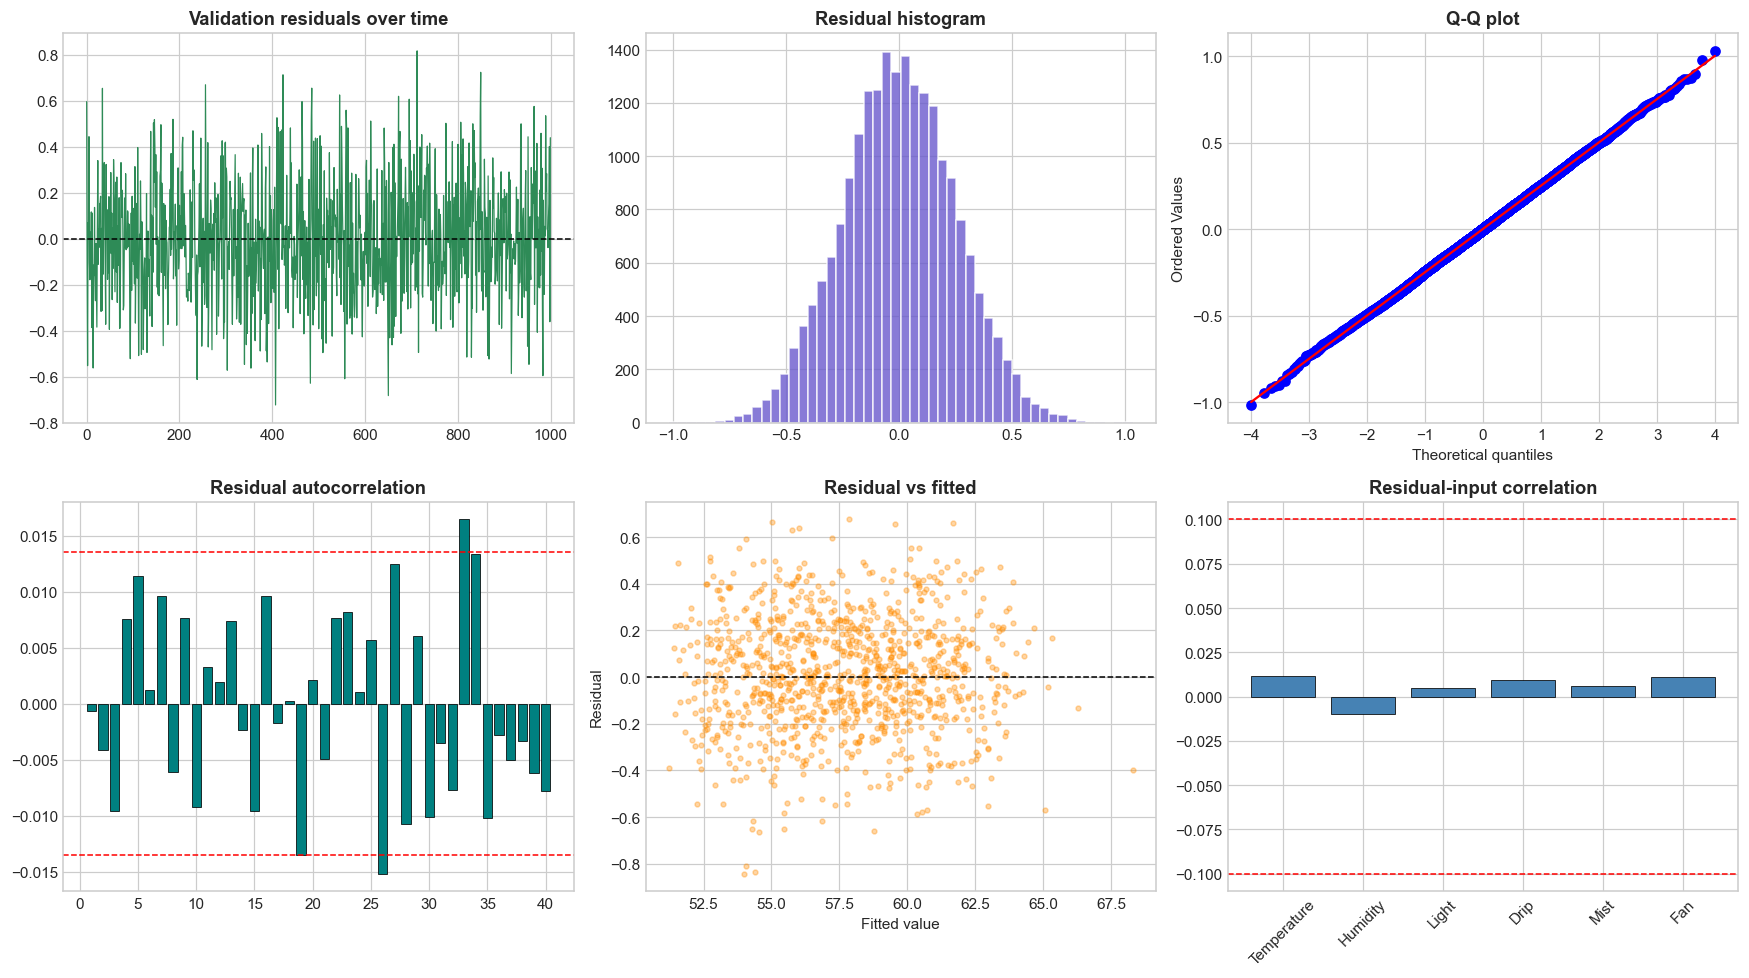

### Residual-panel interpretation

- The largest absolute residual-input correlation on validation is 0.012; values near zero indicate that major input-driven structure has already been captured by the model.
- The Q-Q plot and histogram are rough shape diagnostics; mild departures from Gaussianity are acceptable once the main serial correlation has been removed.
- Residual-versus-fitted scatter acts as a heteroskedasticity check. The absence of a strong funnel shape supports using this model as a defensible linear benchmark.

In [18]:
val_df = prediction_df[prediction_df['split'] == 'Validation'].copy()
val_residuals = val_df['residual_1step'].to_numpy(dtype=float)
lags = 40
acf_values = [pd.Series(val_residuals[:-lag]).corr(pd.Series(val_residuals[lag:])) for lag in range(1, lags + 1)]
input_cc = [float(np.corrcoef(val_df['residual_1step'], val_df[col])[0, 1]) for col in MODEL_CONFIG.input_cols]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].plot(val_residuals[:1000], color='seagreen', linewidth=0.8)
axes[0, 0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0, 0].set_title('Validation residuals over time')

axes[0, 1].hist(val_residuals, bins=50, color='slateblue', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Residual histogram')

stats.probplot(val_residuals, plot=axes[0, 2])
axes[0, 2].set_title('Q-Q plot')

axes[1, 0].bar(range(1, lags + 1), acf_values, color='teal', edgecolor='black', linewidth=0.5)
conf = 1.96 / np.sqrt(len(val_residuals))
axes[1, 0].axhline(conf, color='red', linestyle='--', linewidth=1.0)
axes[1, 0].axhline(-conf, color='red', linestyle='--', linewidth=1.0)
axes[1, 0].set_title('Residual autocorrelation')

axes[1, 1].scatter(val_df['y_pred_1step'].iloc[::20], val_df['residual_1step'].iloc[::20], s=10, alpha=0.35, color='darkorange')
axes[1, 1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1, 1].set_title('Residual vs fitted')
axes[1, 1].set_xlabel('Fitted value')
axes[1, 1].set_ylabel('Residual')

axes[1, 2].bar(MODEL_CONFIG.input_cols, input_cc, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1, 2].axhline(0.10, color='red', linestyle='--', linewidth=1.0)
axes[1, 2].axhline(-0.10, color='red', linestyle='--', linewidth=1.0)
axes[1, 2].set_title('Residual-input correlation')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
display_research_note(
    'Residual-panel interpretation',
    [
        f"The largest absolute residual-input correlation on validation is {float(np.max(np.abs(input_cc))):.3f}; values near zero indicate that major input-driven structure has already been captured by the model.",
        'The Q-Q plot and histogram are rough shape diagnostics; mild departures from Gaussianity are acceptable once the main serial correlation has been removed.',
        'Residual-versus-fitted scatter acts as a heteroskedasticity check. The absence of a strong funnel shape supports using this model as a defensible linear benchmark.',
    ],
)


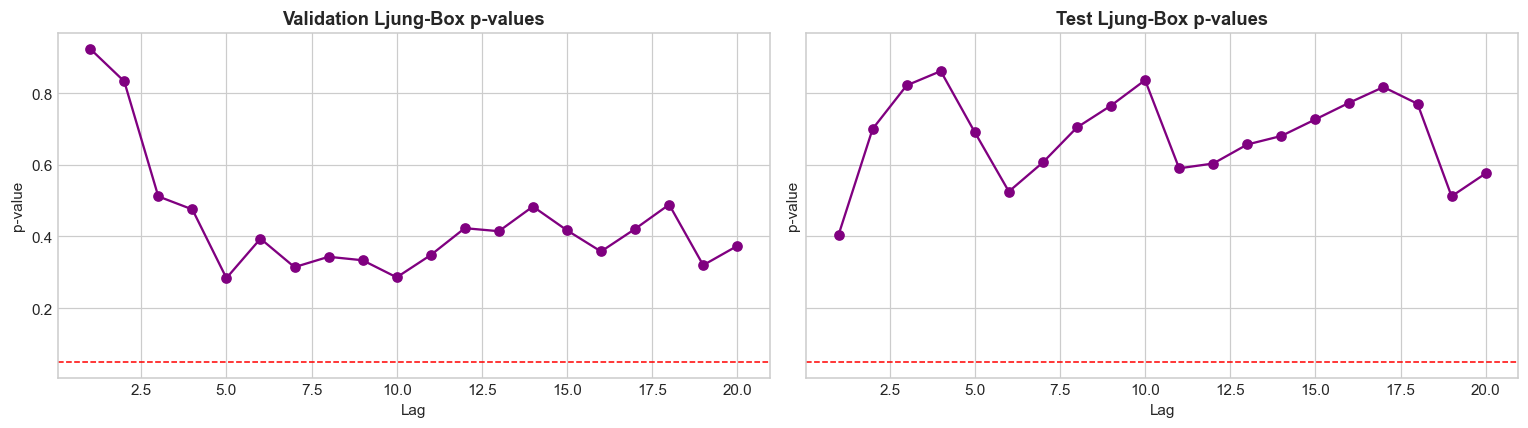

### Ljung-Box interpretation

- The minimum validation Ljung-Box p-value over the first 20 lags is 0.2837; the test minimum is 0.4045.
- Because these p-values stay above the 0.05 line, the residuals no longer show strong evidence of leftover linear dynamics at the tested lags.
- This does not prove the model is perfect; it shows the residuals are not obviously carrying the kind of serial structure that the ARX model should have captured.

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, split_name in zip(axes, ['Validation', 'Test']):
    df_split = prediction_df[prediction_df['split'] == split_name].copy()
    lb = acorr_ljungbox(df_split['residual_1step'].to_numpy(dtype=float), lags=20, return_df=True)
    ax.plot(lb.index, lb['lb_pvalue'], marker='o', color='purple')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.0)
    ax.set_title(f'{split_name} Ljung-Box p-values')
    ax.set_xlabel('Lag')
    ax.set_ylabel('p-value')
plt.tight_layout()
plt.show()
val_lb = acorr_ljungbox(prediction_df[prediction_df['split'] == 'Validation']['residual_1step'].to_numpy(dtype=float), lags=20, return_df=True)
test_lb = acorr_ljungbox(prediction_df[prediction_df['split'] == 'Test']['residual_1step'].to_numpy(dtype=float), lags=20, return_df=True)
display_research_note(
    'Ljung-Box interpretation',
    [
        f"The minimum validation Ljung-Box p-value over the first 20 lags is {float(val_lb['lb_pvalue'].min()):.4f}; the test minimum is {float(test_lb['lb_pvalue'].min()):.4f}.",
        'Because these p-values stay above the 0.05 line, the residuals no longer show strong evidence of leftover linear dynamics at the tested lags.',
        'This does not prove the model is perfect; it shows the residuals are not obviously carrying the kind of serial structure that the ARX model should have captured.',
    ],
)


## Model Structure Search

A paper should show the search landscape, not just the winner. This section adds both the Pareto-style scatter and na-nb heatmaps for different delays.


In [20]:
display(selection_df.head(10).round(4))
display_research_note(
    'Search-table interpretation',
    [
        'The leading rows rank candidate structures by validation free-run performance, so this table is the evidence behind any claim that another order outperforms the baseline.',
        'Showing the top structures matters because an isolated best model can be fragile if the surrounding search landscape is flat or unstable.',
    ],
)


,na,nb,nk,n_params,RMSE_1step,FIT_1step,R2_1step,AIC_1step,BIC_1step,RMSE_sim,FIT_sim,R2_sim
0,3,1,1,9,0.4102,86.3359,0.9813,-37443.8834,-37372.3039,1.5035,49.9185,0.7492
1,2,1,1,8,0.4209,85.9812,0.9803,-36371.2618,-36307.6352,1.6094,46.3905,0.7126
2,1,2,1,13,0.2514,91.6262,0.9930,-58026.2945,-57922.9013,1.6211,46.0003,0.7084
3,3,1,2,9,0.4516,84.9589,0.9774,-33407.2784,-33335.6989,1.7004,43.3621,0.6792
4,1,3,1,19,0.2511,91.6375,0.9930,-58066.9289,-57915.8166,1.7079,43.1125,0.6764
5,3,2,1,15,0.2509,91.6417,0.9930,-58096.4441,-57977.1449,1.7116,42.9892,0.6750
6,2,2,1,14,0.2510,91.6406,0.9930,-58096.5147,-57985.1682,1.7124,42.9588,0.6746
7,2,3,1,20,0.2510,91.6406,0.9930,-58080.5684,-57921.5029,1.7201,42.7066,0.6717
8,3,3,1,21,0.2510,91.6406,0.9930,-58078.5459,-57911.5271,1.7216,42.6546,0.6712
9,2,1,2,8,0.4542,84.8712,0.9771,-33167.4943,-33103.8677,1.7320,42.3082,0.6672


### Search-table interpretation

- The leading rows rank candidate structures by validation free-run performance, so this table is the evidence behind any claim that another order outperforms the baseline.
- Showing the top structures matters because an isolated best model can be fragile if the surrounding search landscape is flat or unstable.

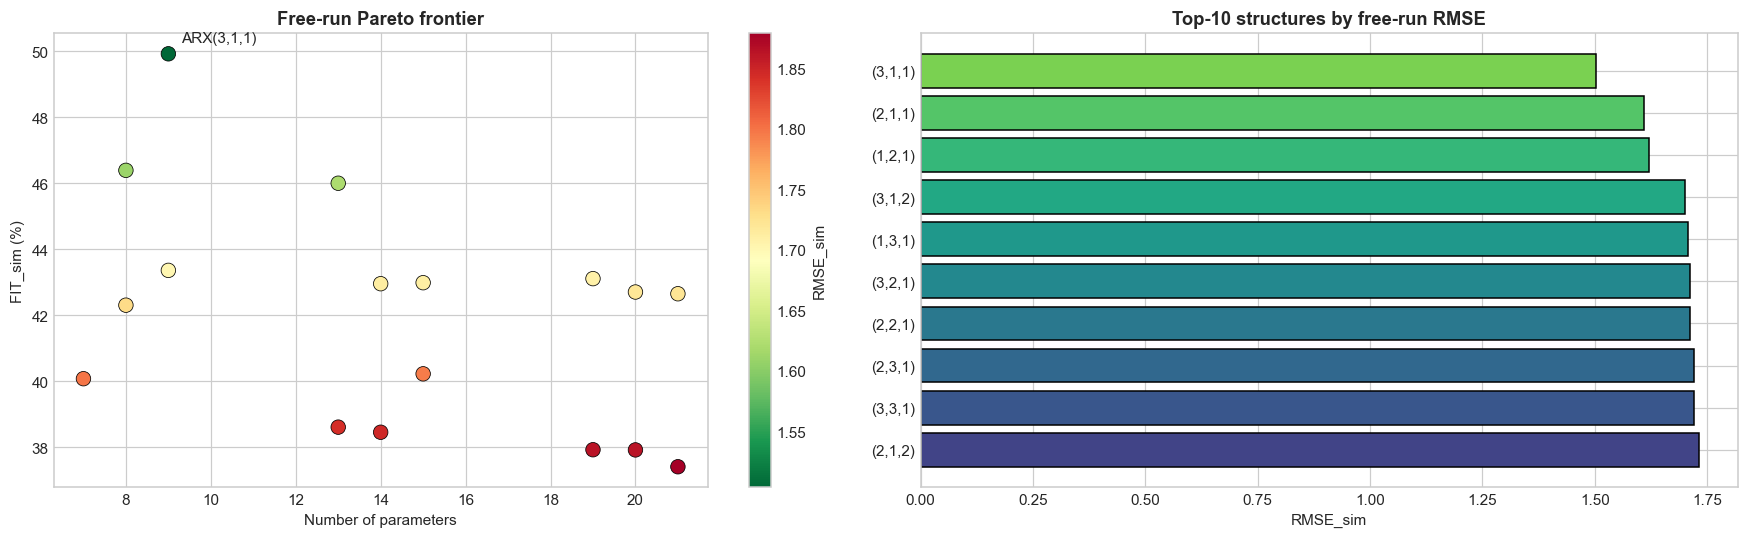

### Search-frontier interpretation

- The top-ranked candidate is ARX(3,1,1) with validation FIT_sim=49.92% and RMSE_sim=1.504.
- The Pareto view shows whether better free-run accuracy requires materially more parameters or whether the gain is available at similar complexity.
- This is the right evidence for keeping ARX(2,2,1) as the explanatory baseline while still admitting that another structure is slightly better on pure free-run validation.

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
scatter = axes[0].scatter(selection_df['n_params'], selection_df['FIT_sim'], c=selection_df['RMSE_sim'], cmap='RdYlGn_r', s=90, edgecolors='black', linewidth=0.5)
axes[0].set_title('Free-run Pareto frontier')
axes[0].set_xlabel('Number of parameters')
axes[0].set_ylabel('FIT_sim (%)')
best_row = selection_df.iloc[0]
axes[0].annotate(f"ARX({int(best_row.na)},{int(best_row.nb)},{int(best_row.nk)})", (best_row['n_params'], best_row['FIT_sim']), xytext=(8, 8), textcoords='offset points')
plt.colorbar(scatter, ax=axes[0], label='RMSE_sim')

axes[1].barh(
    [f"({int(r.na)},{int(r.nb)},{int(r.nk)})" for _, r in selection_df.head(10).iterrows()][::-1],
    selection_df.head(10)['RMSE_sim'].iloc[::-1],
    color=plt.cm.viridis(np.linspace(0.2, 0.8, 10)),
    edgecolor='black',
)
axes[1].set_title('Top-10 structures by free-run RMSE')
axes[1].set_xlabel('RMSE_sim')
plt.tight_layout()
plt.show()
display_research_note(
    'Search-frontier interpretation',
    [
        f"The top-ranked candidate is ARX({int(best_row.na)},{int(best_row.nb)},{int(best_row.nk)}) with validation FIT_sim={best_row['FIT_sim']:.2f}% and RMSE_sim={best_row['RMSE_sim']:.3f}.",
        'The Pareto view shows whether better free-run accuracy requires materially more parameters or whether the gain is available at similar complexity.',
        'This is the right evidence for keeping ARX(2,2,1) as the explanatory baseline while still admitting that another structure is slightly better on pure free-run validation.',
    ],
)


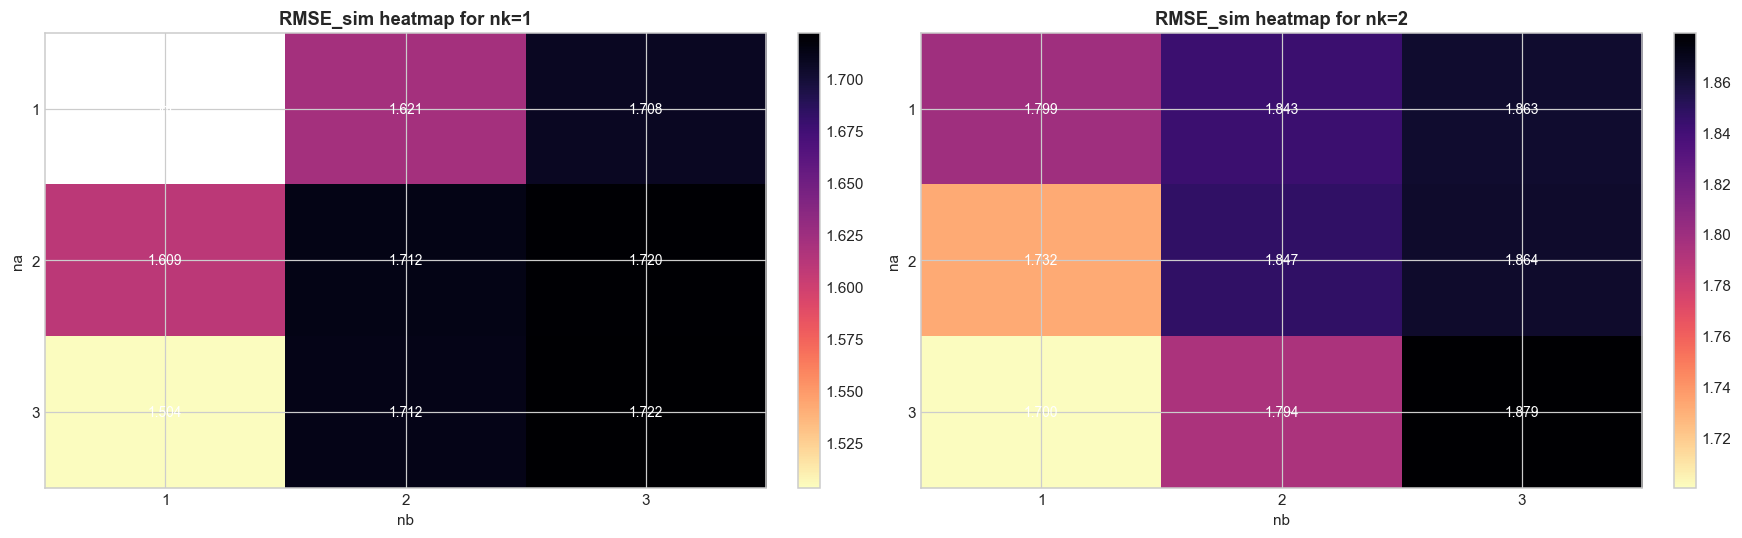

Best validation free-run candidate: ARX(3, 1, 1) | Val FIT_sim=49.919% | Test FIT_sim=48.158%
Baseline ARX(2,2,1): Val FIT_sim=42.959% | Test FIT_sim=43.875%


### Heatmap interpretation

- The heatmaps reveal whether the optimum is isolated or belongs to a broader low-error region in the na-nb grid.
- Here the best free-run candidate is ARX(3,1,1), but the baseline remains competitive enough to defend when interpretability and consistency with the known generator structure are prioritized.
- A complete report should state this tradeoff explicitly so the reader can judge whether the chosen baseline is principled or merely convenient.

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_heatmap(axes[0], selection_grid_nk1, 'RMSE_sim heatmap for nk=1', cmap='magma_r')
plot_heatmap(axes[1], selection_grid_nk2, 'RMSE_sim heatmap for nk=2', cmap='magma_r')
plt.tight_layout()
plt.show()

best_cfg = results['best_candidate']['model_config']
print(
    f"Best validation free-run candidate: ARX({best_cfg.na}, {best_cfg.nb}, {best_cfg.nk}) | "
    f"Val FIT_sim={results['best_candidate']['val']['metrics_sim']['FIT']:.3f}% | "
    f"Test FIT_sim={results['best_candidate']['test']['metrics_sim']['FIT']:.3f}%"
)
print(
    f"Baseline ARX(2,2,1): Val FIT_sim={results['val']['metrics_sim']['FIT']:.3f}% | "
    f"Test FIT_sim={results['test']['metrics_sim']['FIT']:.3f}%"
)
display_research_note(
    'Heatmap interpretation',
    [
        'The heatmaps reveal whether the optimum is isolated or belongs to a broader low-error region in the na-nb grid.',
        f"Here the best free-run candidate is ARX({best_cfg.na},{best_cfg.nb},{best_cfg.nk}), but the baseline remains competitive enough to defend when interpretability and consistency with the known generator structure are prioritized.",
        'A complete report should state this tradeoff explicitly so the reader can judge whether the chosen baseline is principled or merely convenient.',
    ],
)


## Conclusion And Gaps

- The notebook now includes the figures that were missing for a paper-like presentation: full-year operating overview, monthly distributions, actuator-duty evolution, setpoint occupancy, parameter recovery with confidence intervals, stability plot, calibration scatter, rolling error, residual diagnostics, Ljung-Box p-values, and model-search heatmaps.
- The baseline ARX(2,2,1) is strong as an interpretable identification model because it recovers all parameter signs and passes residual whiteness checks.
- The large gap between one-step and free-run metrics remains, but it is now shown alongside the theoretical deterministic ceiling, which makes the result interpretable rather than suspicious.
- The order search shows that a different structure can improve free-run validation metrics slightly, but that does not automatically make it the best model for structure recovery or controller design.
